# IN3050/IN4050 Mandatory Assignment 2, 2025: Supervised Learning
## Author: Oskar Ekeid Idland (oskarei)

## Introduction

### Rules

Before you begin the exercise, review the rules at this website: https://www.uio.no/english/studies/examinations/compulsory-activities/mn-ifi-mandatory.html , in particular the paragraph on cooperation. This is an individual assignment. You are not allowed to deliver together or copy/share source-code/answers with others. Read also the "Routines for handling suspicion of cheating and attempted cheating at the University of Oslo": https://www.uio.no/english/studies/examinations/cheating/index.html 
We do not entirely prohibit the use of generative language models ("smart assistants" like ChatGPT, Llama, Claude or Copilot), but you must clearly acknowledge this at all times, following the UiO guidelines: https://www.uio.no/english/studies/resources/ai_student.html
Note also that you must fully understand _all_ the parts of you submissions, even if you got some help from a generative model. This will be tested during your peer review sessions (https://www.uio.no/studier/emner/matnat/ifi/IN3050/v25/Peer%20review/).
By submitting this assignment, you confirm that you are familiar with the rules and the consequences of breaking them.

### Delivery

**Deadline**: Friday, March 28, 2025, 23:59

Your submission should be delivered in Devilry. You may redeliver in Devilry before the deadline, but include all files in the last delivery, as only the last delivery will be read. You are recommended to upload preliminary versions hours (or days) before the final deadline.

### What to deliver?

You are recommended to solve the exercise in a Jupyter notebook, but you might solve it in a regular Python script if you prefer.

#### Alternative 1
If you prefer not to use notebooks, you should deliver the code, your run results, and a PDF report where you answer all the questions and explain your work.

#### Alternative 2
If you choose Jupyter, you should deliver the notebook. You should answer all questions and explain what you are doing in Markdown. Still, the code should be properly commented. The notebook should contain results of your runs. In addition, you should make a PDF of your solution which shows the results of the runs. (If you can't export: notebook -> latex -> pdf on your own machine, you may do this on the IFI linux machines.)

Here is a list of *absolutely necessary* (but not sufficient) conditions to get the assignment marked as passed:

- You must deliver your code (Python script or Jupyter notebook) you used to solve the assignment.
- The code used for making the output and plots must be included in the assignment. 
- You must include example runs that clearly shows how to run all implemented functions and methods.
- All the code (in notebook cells or python main-blocks) must be runnable. If you have unfinished code that crashes, please comment it out and document what you think causes it to crash. 
- You must also deliver a PDF of the code, outputs, comments and plots as explained above.

Your report/notebook should contain your name and username.

Deliver one single compressed folder (.zip, .tgz or .tar.gz) which contains your complete solution.

Important: if you weren’t able to finish the assignment, use the PDF report/Markdown to elaborate on what you’ve tried and what problems you encountered. Students who have made an effort and attempted all parts of the assignment will get a second chance even if they fail initially. This exercise will be graded PASS/FAIL.

### Goals of the assignment
The goal of this assignment is to get a better understanding of supervised learning with gradient descent. It will, in particular, consider the similarities and differences between linear classifiers and multi-layer feed forward neural networks (multi-layer perceptrons, MLP) and the differences and similarities between binary and multi-class classification. 

### Tools
The aim of the exercises is to give you a look inside the learning algorithms. You may freely use code from the weekly exercises and the published solutions. You should not use machine learning libraries like Scikit-Learn or PyTorch, because the point of this assignment is for you to implement things from scratch. You, however, are encouraged to use tools like NumPy, Pandas and MatPlotLib, which are not ML-specific.

The given precode uses NumPy. You are recommended to use NumPy since it results in more compact code, but feel free to use pure Python if you prefer. 

If anything is unclear, do not hesitate to ask. Also, if you think some assumptions are missing, make your own and explain them!

## Imports

In [1]:
import sklearn # This is only to generate a dataset
import matplotlib
import numpy as np
from tqdm import tqdm
from typing import Literal
from tabulate import tabulate
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
from joblib import Parallel, delayed
from matplotlib.ticker import FuncFormatter

matplotlib.rcParams.update({'font.size': 14, 'figure.figsize': (16, 10)}) 

## Datasets

We start by making a synthetic dataset of 5000 instances and ten classes, with 500 instances in each class. (See https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html regarding how the data are generated.) We choose to use a synthetic dataset---and not a set of natural occuring data---because we are mostly interested in properties of the various learning algorithms, in particular the differences between linear classifiers and multi-layer neural networks together with the difference between binary and multi-class data. In addition, we would like a dataset with instances represented with only two numerical features, so that it is easy to visualize the data. It would be rather difficult (although not impossible) to find a real-world dataset of the same nature. Anyway, you surely can use the code in this assignment for training machine learning models on real-world datasets.

When we are doing experiments in supervised learning, and the data are not already split into training and test sets, we should start by splitting the data. Sometimes there are natural ways to split the data, say training, on data from one year and testing on data from a later year, but if that is not the case, we should shuffle the data randomly before splitting. (OK, that is not necessary with this particular synthetic data set, since it is already shuffled by default by Scikit-Learn, but that will not be the case with real-world data) We should split the data so that we keep the alignment between X (features) and t (class labels), which may be achieved by shuffling the indices. We split into 60% for training, 20% for validation, and 20% for final testing. The set for final testing *must not be used* till the end of the assignment in part 3.

We fix the seed both for data set generation and for shuffling, so that we work on the same datasets when we rerun the experiments. This is done by the `random_state` argument and the `rng = np.random.RandomState(424242)`.

In [2]:
# Generating the dataset
from sklearn.datasets import make_blobs
X, t_multi = make_blobs(n_samples=[500, 500, 500, 500, 500, 500, 500, 500, 500, 500], centers=[[0,1],[4,2],[8,1],[2,0],[6,0],[3,-3],[4,-2],[0,5],[0,4],[-2,-2]], 
                  n_features=2, random_state=424242, cluster_std=[1.0, 2.0, 1.0, 0.5, 0.5, 3.0, 1.0, 0.5, 2.5, 2.5])

In [3]:
# Shuffling the dataset
indices = np.arange(X.shape[0])
rng = np.random.RandomState(424242)
rng.shuffle(indices)
indices[:10]

array([3560, 4674,   49, 1257,  661, 3066, 3834, 4792,  570, 3855])

In [4]:
# Splitting into train, dev and test
X_train = X[indices[:3000],:]
X_val = X[indices[3000:4000],:]
X_test = X[indices[4000:],:]
t_multi_train = t_multi[indices[:3000]]
t_multi_val = t_multi[indices[3000:4000]]
t_multi_test = t_multi[indices[4000:]]

Next, we will  make a second dataset with only two classes by merging the existing labels in (X,t), so that `0-5` become the new `0` and `6-9` become the new `1`. Let's call the new set (X, t2). This will be a binary set.
We now have two datasets:

- Binary set: `(X, t2)`
- Multi-class set: `(X, t_multi)`

In [5]:
t2_train = t_multi_train >= 6
t2_train = t2_train.astype("int")
t2_val = (t_multi_val >= 6).astype("int")
t2_test = (t_multi_test >= 6).astype("int")

We can plot the two traning sets.

Text(0.5, 1.0, 'Multi-class set')

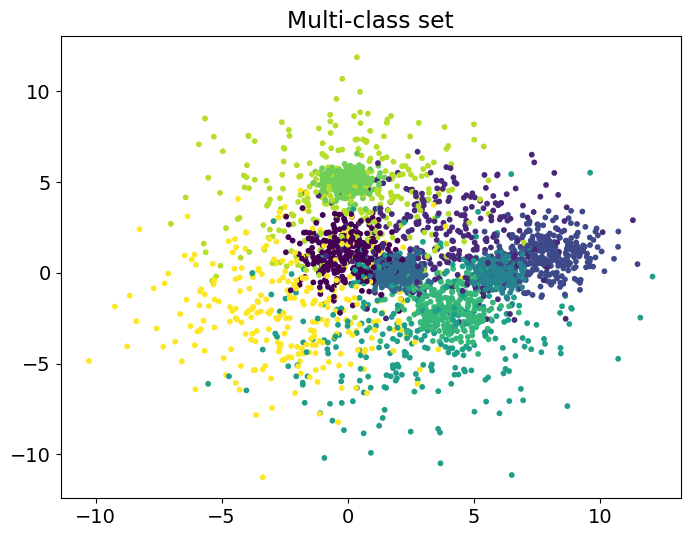

In [6]:
plt.figure(figsize=(8,6)) # You may adjust the size
plt.scatter(X_train[:, 0], X_train[:, 1], c=t_multi_train, s=10.0)
plt.title("Multi-class set")

Text(0.5, 1.0, 'Binary set')

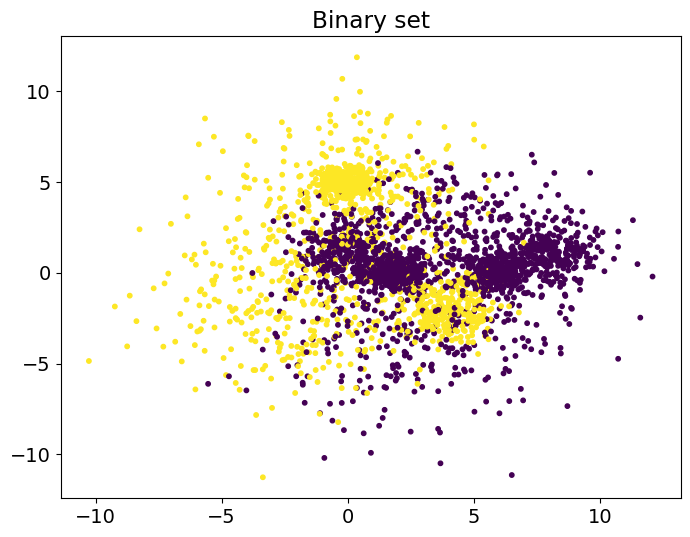

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=t2_train, s=10.0)
plt.title("Binary set")

# Part 1: Linear classifiers
### Linear regression

We see that even the binary set (X, t2) is far from linearly separable, and we will explore how various classifiers are able to handle this. We start with linear regression with the Mean Squared Error (MSE) loss, although it is not the most widely used approach for classification tasks: but we are interested. You may make your own implementation from scratch or start with the solution to the weekly exercise set 6. We include it here with a little added flexibility.

In [8]:
def add_bias(X, bias):
    """X is a NxM matrix: N datapoints, M features
    bias is a bias term, -1 or 1, or any other scalar. Use 0 for no bias
    Return a Nx(M+1) matrix with added bias in position zero
    """
    N = X.shape[0]
    biases = np.ones((N, 1)) * bias # Make a N*1 matrix of biases
    # Concatenate the column of biases in front of the columns of X.
    return np.concatenate((biases, X), axis  = 1) 

In [9]:
class NumpyClassifier():
    """Common methods to all Numpy classifiers --- if any"""
    def fit():
        raise NotImplementedError("Inheriting classes must implement this method")
    def predict():
        raise NotImplementedError("Inheriting classes must implement this method")

In [10]:
class NumpyLinRegClass(NumpyClassifier):
    def __init__(self, bias=-1):
        self.bias=bias
    
    def fit(self, X_train, t_train, lr = 0.1, epochs=10):
        """X_train is a NxM matrix, N data points, M features
        t_train is avector of length N,
        the target class values for the training data
        lr is our learning rate
        """
        
        if self.bias:
            X_train = add_bias(X_train, self.bias)
            
        (N, M) = X_train.shape
        
        self.weights = weights = np.zeros(M)
        
        for epoch in range(epochs):
            weights -= lr / N *  X_train.T @ (X_train @ weights - t_train)      
    
    def predict(self, X, threshold=0.5):
        """X is a KxM matrix for some K>=1
        predict the value for each point in X"""
        if self.bias:
            X = add_bias(X, self.bias)
        ys = X @ self.weights
        return ys > threshold

We can train and test a first classifier (on the binary dataset).

In [11]:
def accuracy(predicted, gold):
    return np.mean(predicted == gold)

In [12]:
classifier = NumpyLinRegClass()
classifier.fit(X_train, t2_train, epochs=10)
accuracy(classifier.predict(X_val), t2_val)

0.638

The following is a small procedure which plots the data set together with the decision boundaries. 
You may modify the colors and the rest of the graphics as you like.
The procedure will also work for multi-class classifiers

In [13]:
def plot_decision_regions(X, t, clf=[], size=(8,6)):
    """Plot the data set (X,t) together with the decision boundary of the classifier clf"""
    # The region of the plane to consider determined by X
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Make a prediction of the whole region
    h = 0.02  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    # Classify each meshpoint.
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=size) # You may adjust this

    # Put the result into a color plot
    plt.contourf(xx, yy, Z, alpha=0.2, cmap = 'tab10')

    plt.scatter(X[:,0], X[:,1], c=t, s=10.0, cmap='tab10')

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("Decision regions")
    plt.xlabel("x0")
    plt.ylabel("x1")

#    plt.show()

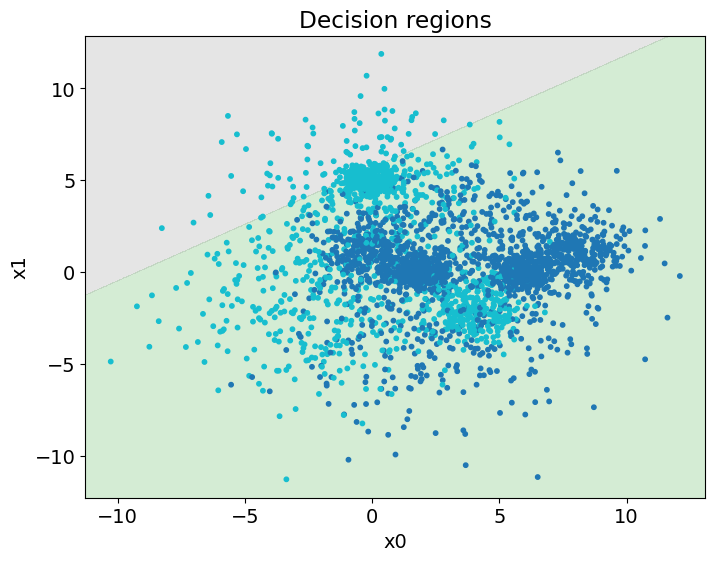

In [14]:
plot_decision_regions(X_train, t2_train, classifier)

### Task: Tuning

The result is far from impressive. 
Remember that a classifier which always chooses the majority class will have an accuracy of 0.6 on this data set.

Your task is to try various settings for the two training hyper-parameters, learning rate and the number of epochs, to get the best accuracy on the validation set. 

Report how the accuracy varies with the hyper-parameter settings. It it not sufficient to give the final hyperparameters. You must also show how you found then and results for alternative values you tried aout.

When you are satisfied with the result, you may plot the decision boundaries, as above.

In [15]:
class HyperparameterTuner:
    def __init__(self, classifier: NumpyClassifier, grid_params: dict[str, np.ndarray], func_params: dict[str, np.ndarray|float|int] = None):
        """
        Initialize GridSearchCV object for hyperparameter optimization.
        
        Parameters
        ----------
        classifier : NumpyClassifier
            An instance of the classifier to optimize hyperparameters for.
        grid_params : dict[str, np.ndarray]
            A dictionary of hyperparameters with the key being the hyperparameter name 
            and the value being the array of hyperparameters.
        func_params : dict[str, np.ndarray|float|int]
            A dictionary of static parameters to pass to the classifier's fit function.
        """
        self._classifier = classifier
        self._grid_params = grid_params
        self._func_params = func_params or {}
        
        self._accuracies = None
        self._best_accuracy = None
        self._best_params = {}
        self._param_arrays = {}
        
    def search(self, X_train, t_train, X_val, t_val):
        """
        Performs grid search over the hyperparameters.
        
        Parameters
        ----------
        X_train : np.ndarray
            The training data.
        t_train : np.ndarray
            The training targets.
        X_val : np.ndarray
            The validation data.
        t_val : np.ndarray
            The validation targets.
            
        Returns
        -------
        self : GridSearchCV
            The fitted GridSearchCV object.
        """
        # Store the data the model was trained on
        self._X_train = X_train
        self._t_train = t_train
        self._X_val = X_val
        self._t_val = t_val
        
        
        param_names  = list(self.grid_params.keys())
        param_arrays = list(self.grid_params.values())
            
        param_name1,  param_name2  = param_names
        param_array1, param_array2 = param_arrays
        
        self._param_arrays = {param_name1: param_array1, param_name2: param_array2}
        
        nx = len(param_array1)
        ny = len(param_array2)
        self._accuracies = np.zeros((ny, nx))
        
        # Function to evaluate a single set of hyperparameters
        def evaluate_hyperparams(classifier: NumpyClassifier, param1, param2):
            # Creates a fresh classifier instance as we are in parallel
            
            # Parameter dictionaries for passing keyword arguments
            func_kwarg_1 = {param_name1: param1}
            func_kwarg_2 = {param_name2: param2}
            
            # Train and evaluate
            classifier.fit(X_train=X_train, t_train=t_train, **func_kwarg_1, **func_kwarg_2, **self.func_params)
            return accuracy(classifier.predict(X_val), t_val)

        # Run grid search with outer loop sequential and inner loop parallel
        for j, param1 in enumerate(tqdm(param_array1, desc=param_name1)):
            results = Parallel(n_jobs=-1)(delayed(evaluate_hyperparams)(self.classifier, param1, param2) for param2 in param_array2)
            
            for i, acc in enumerate(results):
                self._accuracies[i, j] = acc
        
        self._find_best_params()
        
        # Train the classifiers with the best hyperparameters
        self._best_classifiers = []
        for i in range(len(self.best_params[param_name1])):
            best_params = {param_name1: self.best_params[param_name1][i], param_name2: self.best_params[param_name2][i]}
            classifier = self.classifier.__class__()
            classifier.fit(X_train, t_train, **best_params, **self.func_params)
            self._best_classifiers.append(classifier)
        
    
    def _find_best_params(self):
        """Find the best hyperparameters based on validation accuracy."""
        param_names = list(self.param_arrays.keys())
        param_values = list(self.param_arrays.values())
        
        self._best_accuracy = np.max(self.accuracies)
        best_idx = np.where(self.accuracies == self.best_accuracy)
        
        best_y_idx = best_idx[0]
        best_x_idx = best_idx[1]
        
        best_x = param_values[0][best_x_idx]
        best_y = param_values[1][best_y_idx]
        
        self._best_params = {
            param_names[0]: best_x,
            param_names[1]: best_y
        }
        
    
    
    def sort_best_params(self, primary_param, descending=False):
        """
        Sort the best parameters by the specified parameter.
        
        Parameters
        ----------
        primary_param : str
            The parameter to sort by.
        descending : bool
            Whether to sort in descending order.
            
        Returns
        -------
        sorted_params : dict
            A dictionary with sorted parameter values.
        """
            
        param_names = list(self.best_params.keys())
        other_param = param_names[1] if param_names[0] == primary_param else param_names[0]
        
        primary_array = self.best_params[primary_param]
        secondary_array = self.best_params[other_param]
        
        # Get the indices that would sort the primary array
        sort_indices = np.argsort(primary_array)
        # If descending is True, reverse the order
        if descending:
            sort_indices = sort_indices[::-1]
        # Sort both arrays using the same indices
        sorted_primary = primary_array[sort_indices]
        sorted_secondary = secondary_array[sort_indices]
        
        return {primary_param: sorted_primary, other_param: sorted_secondary}
    
    
    def plot_search(self, labels: tuple[str] = None, logx=False, logy=False) -> plt.Figure:
        """
        Plots the validation accuracy for different hyperparameters.
        
        Parameters
        ----------
        labels : tuple[str] (optional)
            The labels for the x and y axes.
        logx : bool (optional)
            Whether to use logarithmic scale for x-axis. Default is False
        logy : bool (optional)
            Whether to use logarithmic scale for y-axis. Default is False
            
        Returns
        -------
        fig : plt.Figure
            The figure object.
        """
        
        # Get parameter names and arrays
        param_names = list(self.param_arrays.keys())
        x_array = self.param_arrays[param_names[0]]
        y_array = self.param_arrays[param_names[1]]
        
        # Define scaling functions
        def log10(array):
            return np.log10(array)
        
        def identity(array):
            return array
        
        # Set scaling based on parameters
        scale_x = log10 if logx else identity
        scale_y = log10 if logy else identity
        
        # Create meshgrid for contour plot
        XX, YY = np.meshgrid(scale_x(x_array), scale_y(y_array))
        
        # Create contour plot
        contour = plt.contourf(XX, YY, self.accuracies, levels=len(np.unique(self.accuracies).ravel()), cmap='PiYG')
        
        # Add colorbar
        plt.colorbar(contour, label='Validation Accuracy', format=FuncFormatter('{:.2%}'.format))
        
        # Add contour lines
        contour_lines = plt.contour(XX, YY, self.accuracies, 10, colors='white', linewidths=0.75, alpha=0.9)
        plt.clabel(contour_lines, inline=True, fontsize=8, fmt='%.3f')
        
        # Get best parameters
        best_param1 = self.best_params[param_names[0]]
        best_param2 = self.best_params[param_names[1]]
        
        # Ensure we have arrays for compatibility
        if np.isscalar(best_param1):
            best_param1 = np.array([best_param1])
        if np.isscalar(best_param2):
            best_param2 = np.array([best_param2])
        
        # Create parameter string for label
        parameter_str = ''.join(f'\n({param_names[0]}={x:.3g}, {param_names[1]}={y:.3g})' 
                            for x, y in zip(best_param1, best_param2))
        
        # Plot first best hyperparameter with label
        plt.scatter(scale_x(best_param1[0]), scale_y(best_param2[0]), color='hotpink', s=200, marker='*',
                edgecolors='white', linewidths=1.5, zorder=5,
                label=f'Highest: {self.best_accuracy:.2%}' + parameter_str)
        
        # Plot additional best hyperparameters if there are multiple
        for param1, param2 in zip(best_param1[1:], best_param2[1:]):
            plt.scatter(scale_x(param1), scale_y(param2), color='hotpink', s=200, marker='*',
                    edgecolors='white', linewidths=1.5, zorder=5)
        
        # Add labels
        if labels:
            plt.xlabel(labels[0])
            plt.ylabel(labels[1])
        else:
            plt.xlabel(param_names[0] + r" [log$_{10}$]"*logx)
            plt.ylabel(param_names[1] + r" [log$_{10}$]"*logy)
        
        # Format ticks for log scales
        if logx:
            plt.xticks([np.log10(param) for param in x_array], 
                    [f'{param:.1e}' for param in x_array], rotation=45)
        if logy:
            plt.yticks([np.log10(param) for param in y_array],
                    [f'{param:.1e}' for param in y_array])
        
        plt.legend()
        plt.grid(alpha=0.2)
        
        fig = plt.gcf()
        return fig
    
    def plot_regions(self, n=0) -> None:
        """
        Plot the data set (X,t) together with the decision boundary of the classifier clf
        
        Parameters
        ----------
        n : int (optional)
            The index of the best pair of hyperparameters to use. Default is 0.
        """
        assert self.best_params, "No best hyperparameters found. Run search() first."
        assert n < len(self.best_classifiers), f'Index {n} out of range. There are {len(self.best_classifiers)} sets of hyperparameters giving the best accuracies.'
        classifier = self.best_classifiers[n]
        plot_decision_regions(self.X_train, self.t_train, classifier)
        plt.show()
        
    def plot_loss(self, n=0) -> plt.Figure:
        '''
        Plots the loss for a set of the best hyperparameters.
        
        Parameters
        ----------
        n : int (optional)
            The index of the best pair of hyperparameters to use. Default is 0.
        '''
        assert self.best_params, "No best hyperparameters found. Run search() first."
        assert n < len(self.best_classifiers), f'Index {n} out of range. There are {len(self.best_classifiers)} sets of hyperparameters giving the best accuracies.'
        
        classifier = self.best_classifiers[n]
        classifier.plot_loss()
        
        fig = plt.gcf()
        return fig
    
    @property
    def classifier(self):
        """Get the classifier."""
        return self._classifier
    
    @property
    def grid_params(self):
        """Get the grid parameters."""
        return self._grid_params
    
    @property
    def func_params(self):
        """Get the function parameters."""
        return self._func_params
        
    @property
    def best_classifiers(self):
        """Get the best classifiers."""
        return self._best_classifiers
        
    @property
    def best_accuracy(self):
        """Get the best validation accuracy."""
        return self._best_accuracy
    
    @property
    def best_params(self):
        """Get the best hyperparameters."""
        return self._best_params
    
    @property
    def param_arrays(self):
        """Get the parameter arrays."""
        return self._param_arrays
    
    @property
    def accuracies(self):
        """Get the validation accuracies."""
        return self._accuracies
    
    @property
    def X_train(self):
        """Get the training data."""
        return self._X_train
    
    @property
    def t_train(self):
        """Get the training targets."""
        return self._t_train
    
    @property
    def X_val(self):
        """Get the validation data."""
        return self._X_val
    
    @property
    def t_val(self):
        """Get the validation targets."""
        return self._t_val

In [16]:
start = 10
stop = 400
step = 10
n_x = (stop - start) // step
epochs = np.arange(start, stop, step, dtype=int)

n_y = 20
learning_rates = np.logspace(-3, -1, n_y)

grid_params = {
    'epochs': epochs,
    'lr': learning_rates
}

tuner_linreg = HyperparameterTuner(NumpyLinRegClass(), grid_params)

In [17]:
tuner_linreg.search(X_train, t2_train, X_val, t2_val)

epochs: 100%|██████████| 39/39 [00:12<00:00,  3.11it/s]


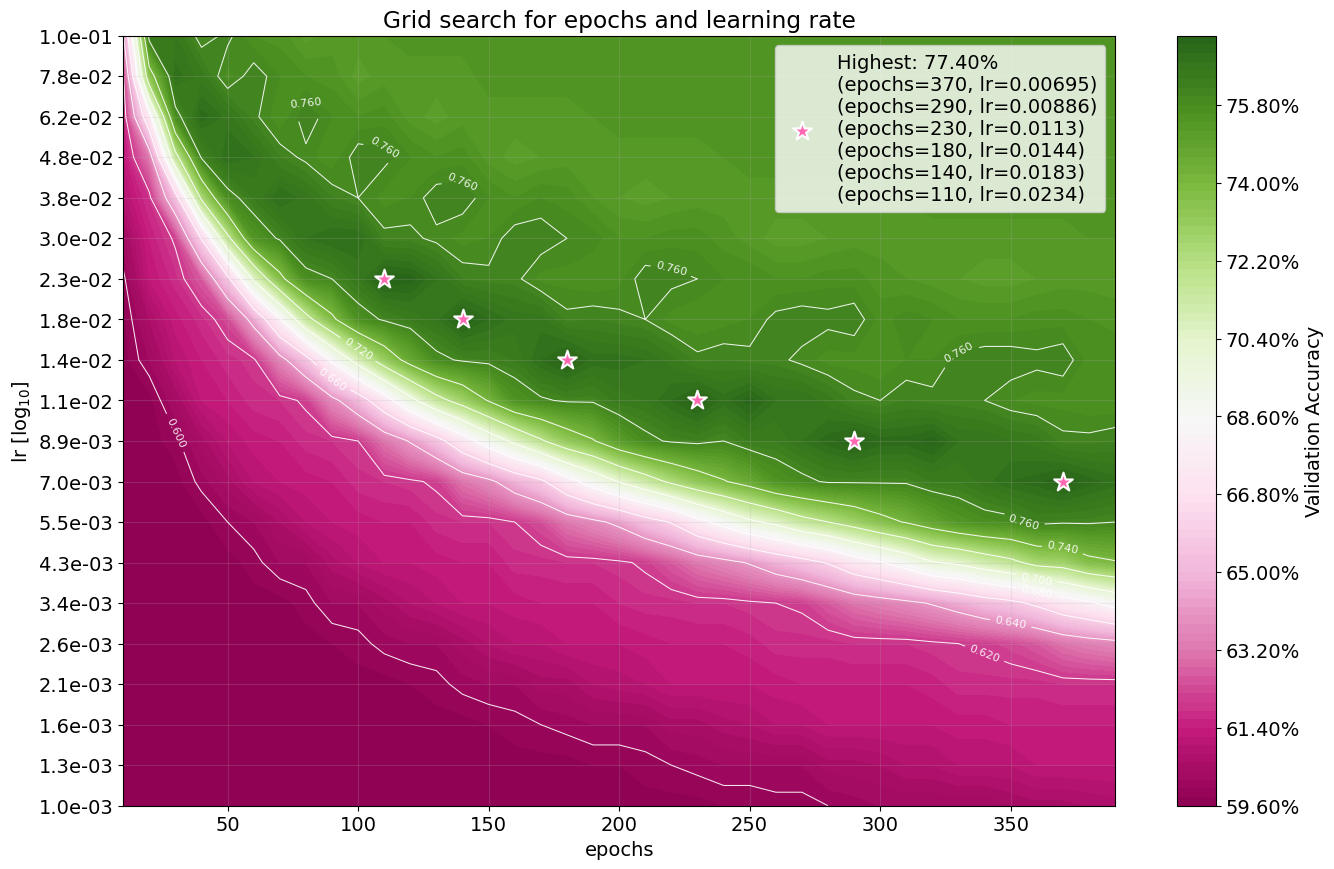

In [18]:
tuner_linreg.plot_search(logy=True)
plt.title("Grid search for epochs and learning rate")
plt.show()

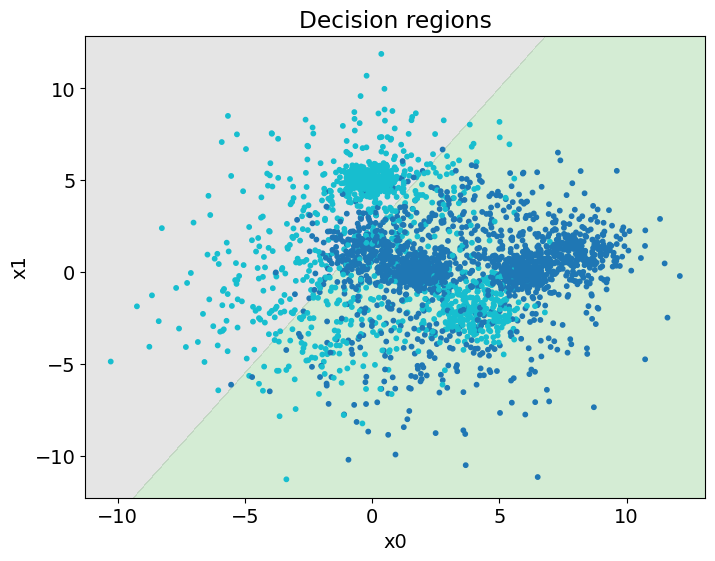

In [19]:
tuner_linreg.plot_regions()

#### Conclusion
- Using a grid search, we find the best hyperparameters for the linear regression classifier. 
- We get an accuracy of 0.7740, which is as good as we can expect for a linear classifier on this dataset. 

### Task: Scaling

We have seen in the lectures that scaling the data may improve training speed and sometimes the performance. 

- Implement the standard scaler (normalizer); you can also try other scaling techniques
- Scale the data
- Train the model on the scaled data
- Experiment with hyper-parameter settings and see whether you can speed  up or improve the training.
- Report final hyper-parameter settings and show how you found them.

In [20]:
def standard_scaler(X_train: np.ndarray, X_val: np.ndarray) -> np.ndarray:
    '''
    Standard scaling of training and validation data with respect to the training data.
    
    Parameters:
    X_train: np.ndarray
        Training data.
    X_val: np.ndarray
        Validation data.
        
    Returns:
    X_train_scaled: np.ndarray
        Scaled training data.
    X_val_scaled: np.ndarray
        Scaled validation data.
    '''
    μ = np.mean(X_train, axis=0)
    σ = np.std(X_train, axis=0)
    
    X_train_scaled = (X_train - μ) / σ
    X_val_scaled   = (X_val   - μ) / σ
    
    return X_train_scaled, X_val_scaled

In [21]:
X_train_scaled, X_val_scaled = standard_scaler(X_train, X_val)

tuner_linreg_scaled = HyperparameterTuner(NumpyLinRegClass(), grid_params)

tuner_linreg_scaled.search(X_train_scaled, t2_train, X_val_scaled, t2_val)

epochs: 100%|██████████| 39/39 [00:10<00:00,  3.80it/s]


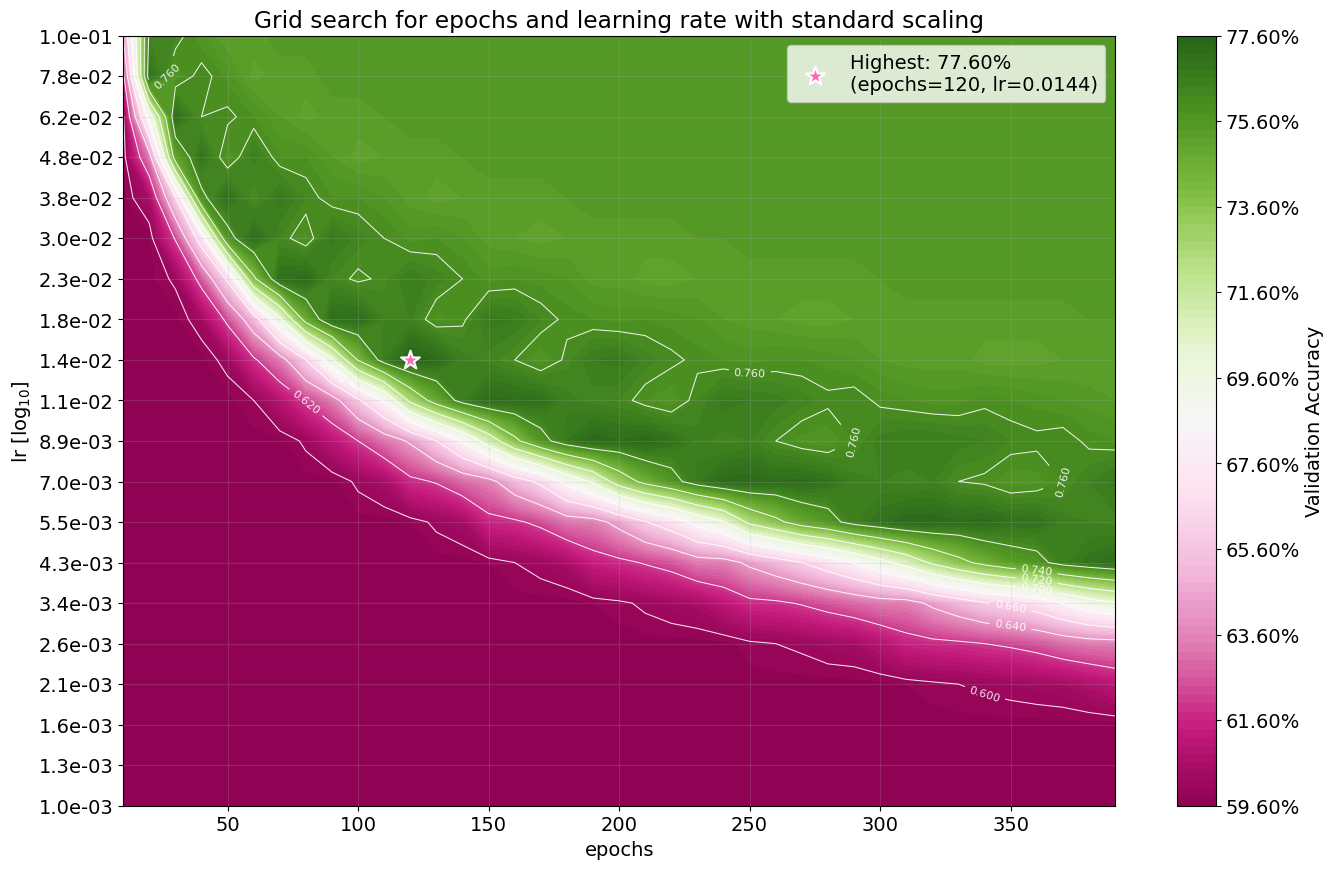

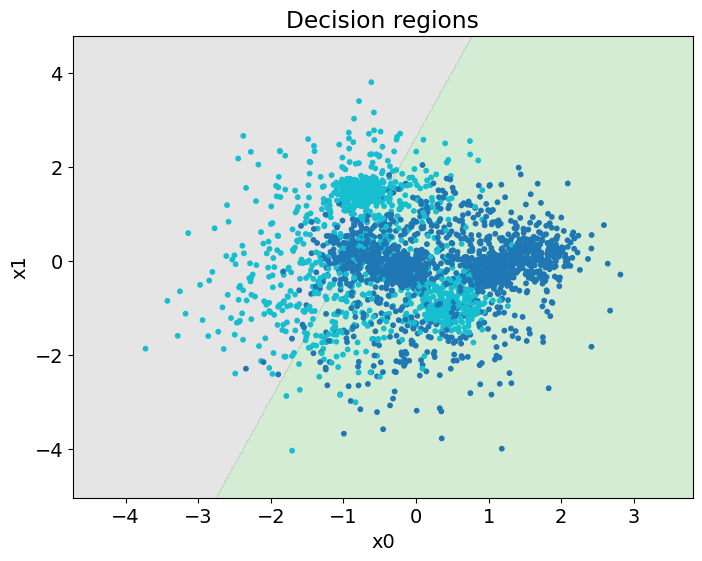

In [22]:

tuner_linreg_scaled.plot_search(logy=True)
plt.title("Grid search for epochs and learning rate with standard scaling")
plt.show()

tuner_linreg_scaled.plot_regions()
plt.show()

#### Conclusion
- Scaling the data gave a tiny bit better results.
- Scaling gave us a much larger larger range of hyperparameters giving good results. This is beneficial as reducing the number of epochs will increase the training speed.

## Logistic regression
a) You should now implement a logistic regression classifier similarly to the classifier based on linear regression.
You may use the code from the solution to weekly exercise set week06.

b) In addition to the method `predict()` which predicts a class for the data, include a method `predict_probabilities()` which predicts the probability of the data belonging to the positive class.

c) So far, we have not calculated the loss explicitly in the code. Extend the code to calculate the loss on the training set for each epoch and to store the losses such that the losses can be inspected after training. The prefered loss for logistic regression is binary cross-entropy, but you can also try mean squared error. The most important is that your implementation of the loss corresponds to your implementation of the gradient descent.
Also, calculate and store accuracies after each epoch.

d) In addition, extend the `fit()` method with optional arguments for a validation set (X_val, t_val). If a validation set is included in the call to `fit()`, calculate the loss and the accuracy for the validation set after each epoch. 

e) The training runs for a number of epochs. We cannot know beforehand for how many epochs it is reasonable to run the training. One possibility is to run the training until the learning does not improve much. Extend the `fit()` method with two keyword arguments, `tol` (tolerance) and `n_epochs_no_update` and stop training when the loss has not improved with more than `tol` after `n_epochs_no_update` (to save compute and potentially avoid over-fitting). A possible default value for `n_epochs_no_update` is 2. Also, add an attribute to the classifier which tells us after fitting how many epochs it was trained for.

f) Train classifiers with various learning rates, and with varying values for `tol` for finding the optimal values. Also consider the effect of scaling the data.

g) After a succesful training, for your best model, plot both training loss and validation loss as functions of the number of epochs in one figure, and both training and validation accuracies as functions of the number of epochs in another figure. Comment on what you see. Are the curves monotone? Is this as expected?

In [23]:
class NumpyLogReg(NumpyClassifier):
    def __init__(self, bias=-1, seed=420):
        self.bias = bias
        self.seed = seed

    def fit(self, X_train, t_train, lr = 0.1, epochs=10, X_val=None, t_val=None, tol=1e-5, n_epochs_no_update=2, min_epochs=0):
        '''
        Fit the model to the data
        
        Parameters
        -----------
        X_train: np.ndarray
            Training data
        t_train: np.ndarray
            Training target values
        lr: float [opt] 
            Learning rate. Default is 0.1
        epochs: int [opt]
            Number of epochs. Default is 10
        X_val: np.ndarray [opt]
            Validation data
        t_val: np.ndarray [opt]
            Validation target values
        tol: float [opt]
            Tolerance for early stopping after reaching `n_epochs_no_update`. Default is 1e-5
        n_epochs_no_update: int [opt]
            Number of epochs which to check for improvement greater than `tol`. Default is 2
        min_epochs: int [opt]
            Minimum number of epochs to run before early stopping. Default is 0
        '''
        self.fit_params = {'lr': lr, 'epochs': epochs, 'tol': tol, 'n_epochs_no_update': n_epochs_no_update, 'min_epochs': min_epochs}
        
        validation: bool = X_val is not None and t_val is not None
        
        if self.bias:
            X_train = add_bias(X_train, self.bias)
            if validation:
                X_val = add_bias(X_val, self.bias)
        
        (N, M) = X_train.shape
        
        
        np.random.seed(self.seed)
        self.weights = weights = np.random.rand(M)
        
        self.loss = []
        self.accuracy = []
        self.val_loss = []
        self.val_accuracy = []
        self.convergence_epoch = None
        
            
        for e in range(epochs):
            if e > min_epochs:
                loss_avg = self.loss[e-n_epochs_no_update]
                improvement = loss_avg - self.loss[-1]
                if improvement < tol:
                    # print(f'Converged after {e} epochs' )
                    # print(f'Params: lr={lr}, epochs={epochs}, tol={tol}, n_epochs_no_update={n_epochs_no_update}, min_epochs={min_epochs}')
                    self.convergence_epoch = e
                    break
            
            weights -= lr / N *  X_train.T @ (self.forward(X_train) - t_train) 
            self.loss.append(self.cross_entropy_loss(X_train, t_train))
            self.accuracy.append(accuracy(self.predict(X_train), t_train))
            
            
            if validation:   
                self.val_loss.append(self.cross_entropy_loss(X_val, t_val))
                self.val_accuracy.append(accuracy(self.predict(X_val), t_val))
                
        if self.convergence_epoch is None:
            self.convergence_epoch = epochs
        
    def logistic(self, x):
        return 1 / (1 + np.exp(-x))
    
    def forward(self, X):
        return self.logistic(X @ self.weights)
    
    def predict(self, X, threshold=0.5):
        is_dimensions_one_off = X.shape[1] == self.weights.shape[0] - 1
        if self.bias and is_dimensions_one_off:
            X = add_bias(X, self.bias)
            
        ys = self.forward(X)
        return ys > threshold
    
    def predict_probabilites(self, X):
        is_dimensions_one_off = X.shape[1] == self.weights.shape[0] - 1
        if self.bias and is_dimensions_one_off:
            X = add_bias(X, self.bias)
        return self.forward(X)
    
    def cross_entropy_loss(self, X_train, t_train):
        p = self.predict_probabilites(X_train)
        return -np.mean(t_train * np.log(p) + (1 - t_train) * np.log(1 - p))
    
    
    def plot_loss(self) -> plt.Figure:
        '''
        Plots the loss of the classifier.
        '''
        plt.plot(self.loss, label='Training Loss', color='darkblue')
        plt.plot(self.val_loss, label='Validation Loss', color='aqua', linestyle='--')
        lines_loss, labels_loss = plt.gca().get_legend_handles_labels()
        plt.ylabel('Cross-Entropy Loss', color='blue')
        plt.yticks(color='blue')
        plt.xlabel('Epochs')

        plt.twinx()

        plt.plot(self.accuracy, label='Training Accuracy', color='darkgreen')
        plt.plot(self.val_accuracy, label='Validation Accuracy', color='lime', linestyle='--')
        lines_acc, labels_acc = plt.gca().get_legend_handles_labels()
        plt.ylabel('Accuracy', color='green')
        plt.yticks(color='green')
        percentage_formatter = lambda x, _: f'{x:.1%}'
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(percentage_formatter))

        plt.title(f'Training and Validation Loss and accuracy converging at epoch {self.convergence_epoch}/{self.fit_params["epochs"]}')
        plt.legend(lines_loss + lines_acc, labels_loss + labels_acc)
        
        fig = plt.gcf()
        return fig    

### Unscaled

In [24]:
cl_logreg = NumpyLogReg()
epoch = 2000
n_epochs_no_update = 10
min_epochs = 100

lr_start = -4
lr_stop = -1
n_lr = (lr_stop - lr_start + 1) * 2
learning_rates_logreg = np.logspace(lr_start, lr_stop, n_lr)

tol_start = -6
tol_stop = -1
n_tol = (tol_stop - tol_start + 1) * 4
tolerances = np.logspace(tol_start, tol_stop, n_tol)

# Dynamic variables that will be iterated over in grid search
grid_params = {'tol': tolerances, 'lr': learning_rates_logreg}
# Static variables that will be passed to the fit function
func_params = {'epochs': epoch, 'X_val': X_val, 't_val': t2_val, 'n_epochs_no_update': n_epochs_no_update, 'min_epochs': min_epochs}

tuner_logreg = HyperparameterTuner(NumpyLogReg(), grid_params, func_params)

In [25]:
tuner_logreg.search(X_train, t2_train, X_val, t2_val)

tol: 100%|██████████| 24/24 [00:16<00:00,  1.49it/s]


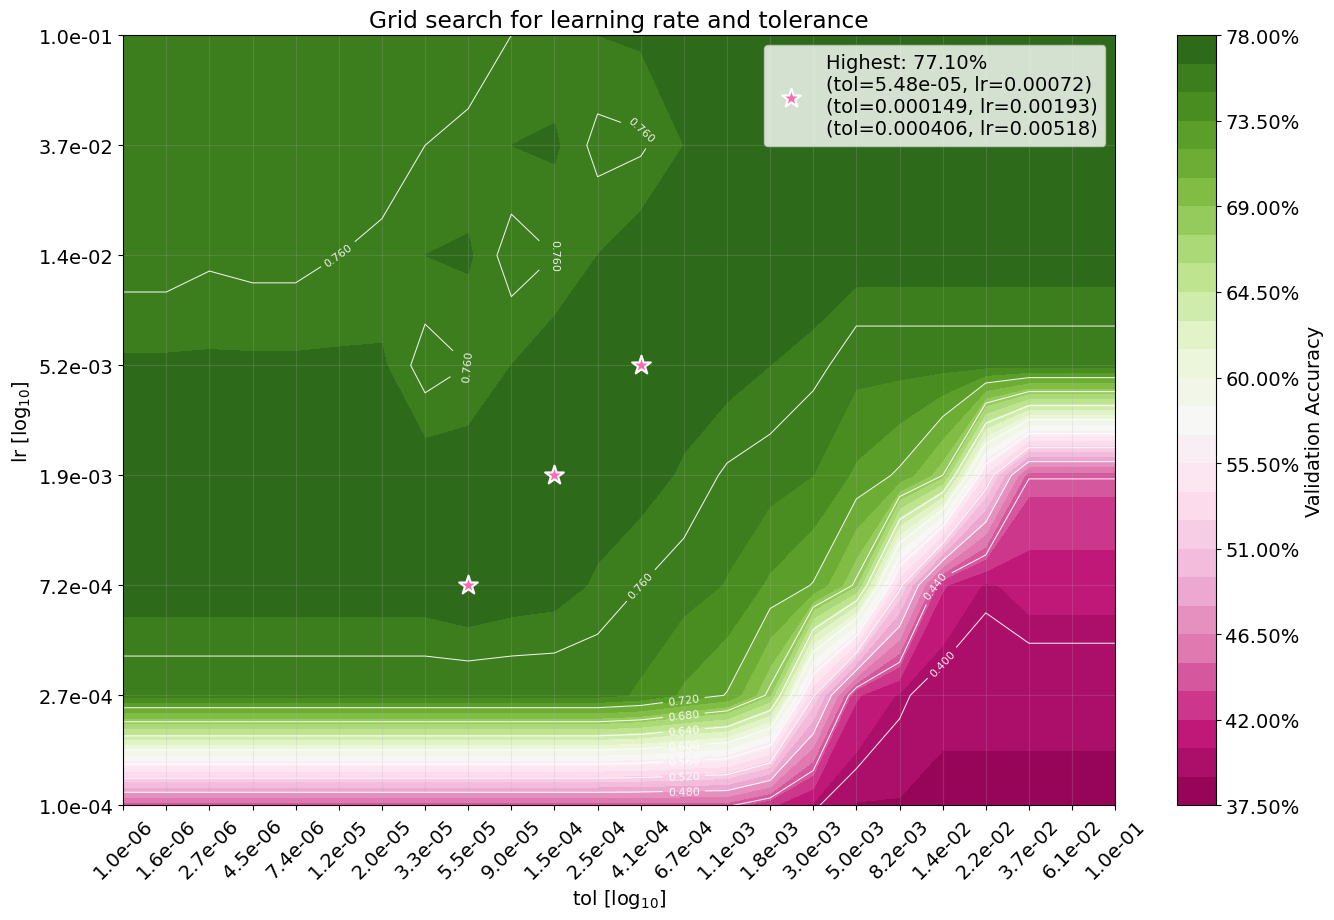

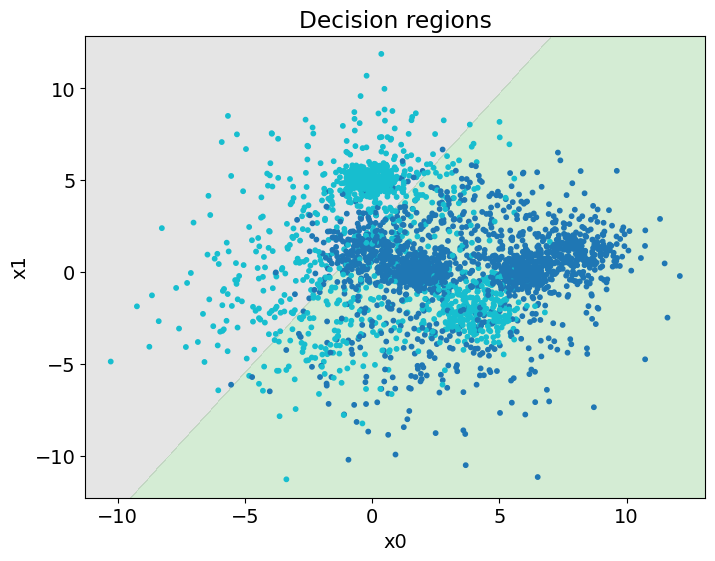

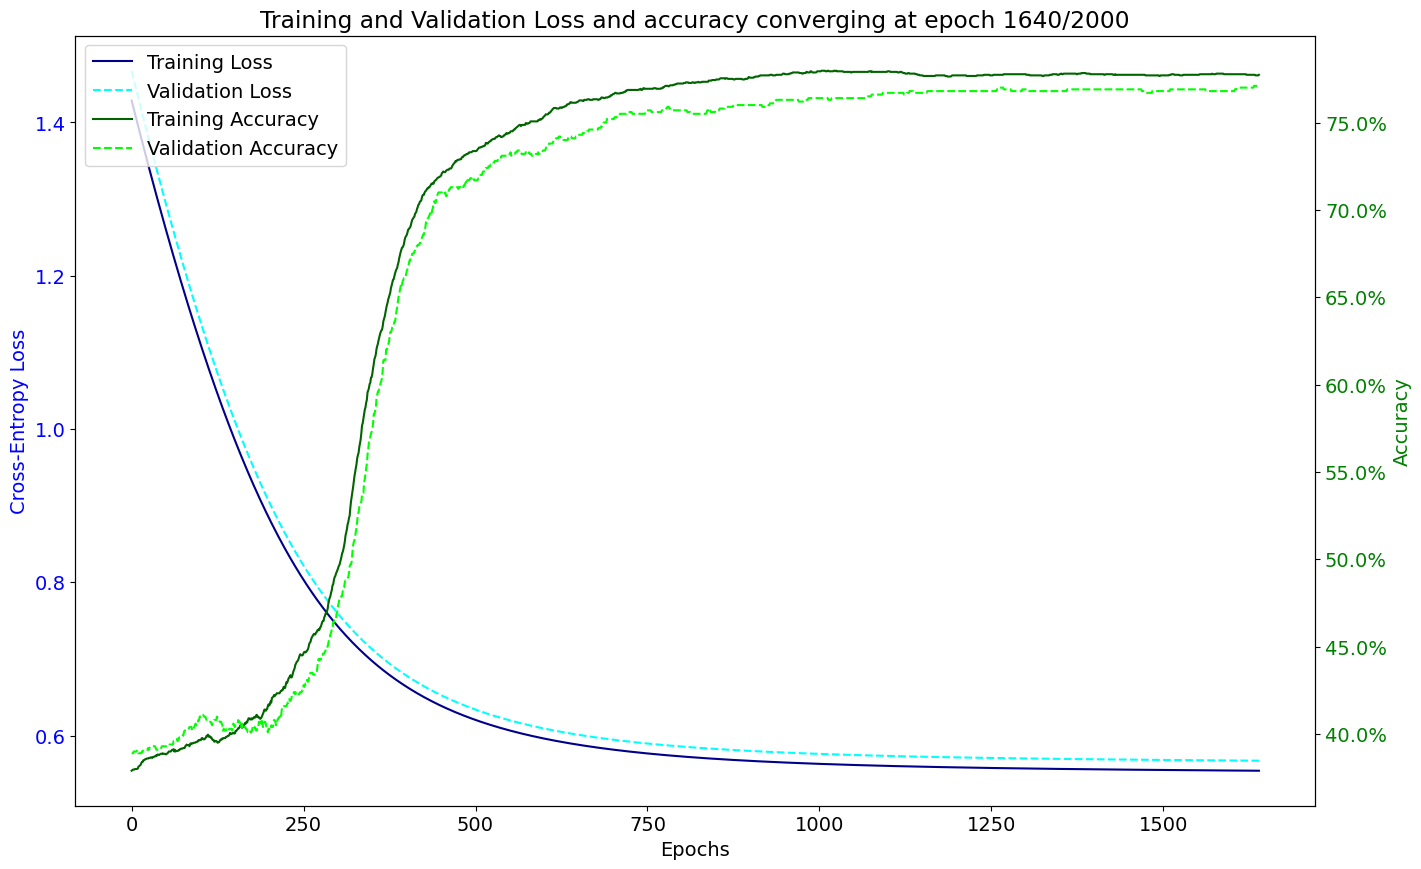

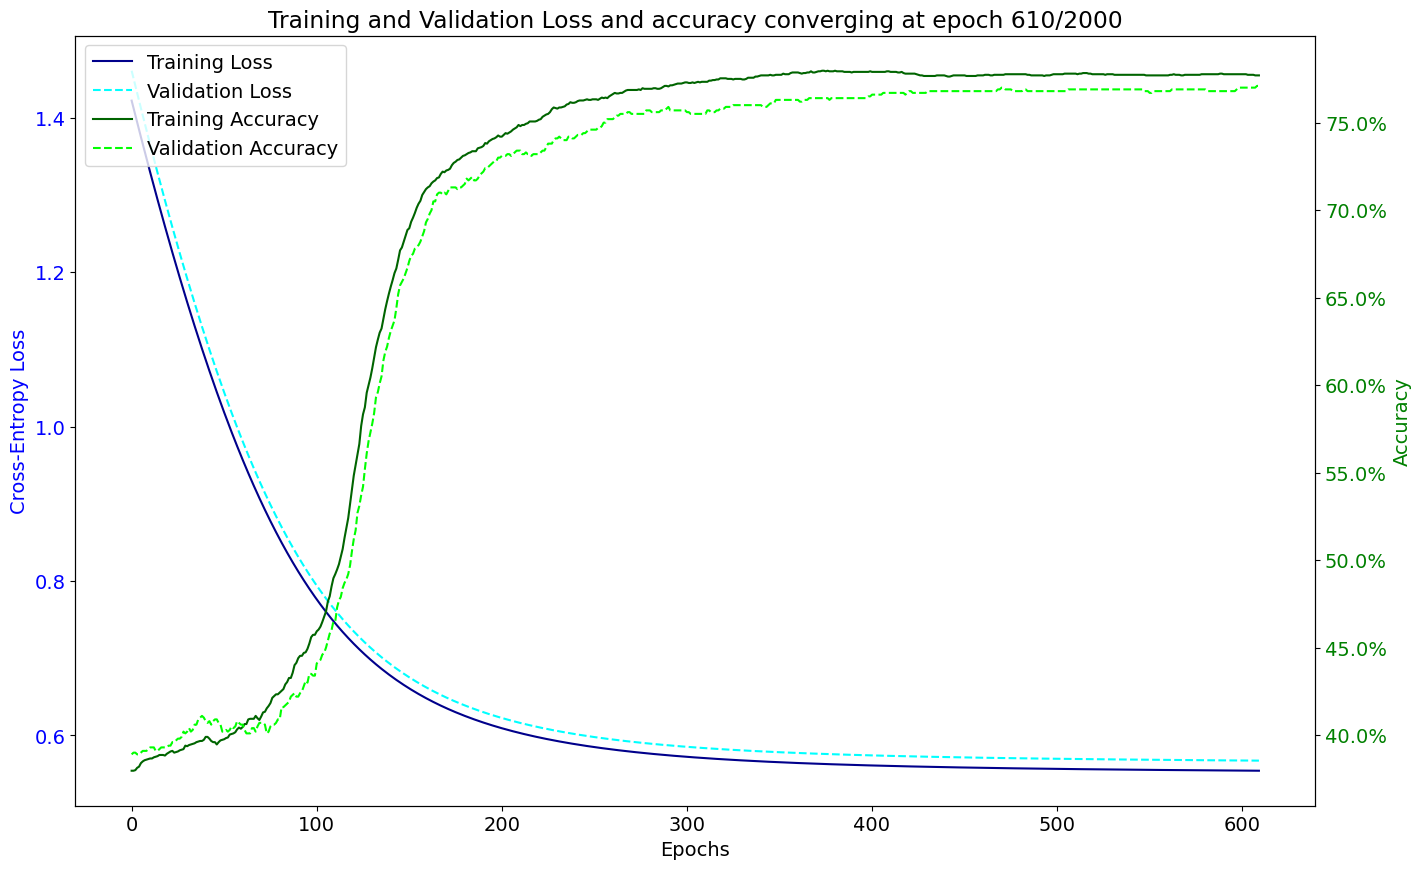

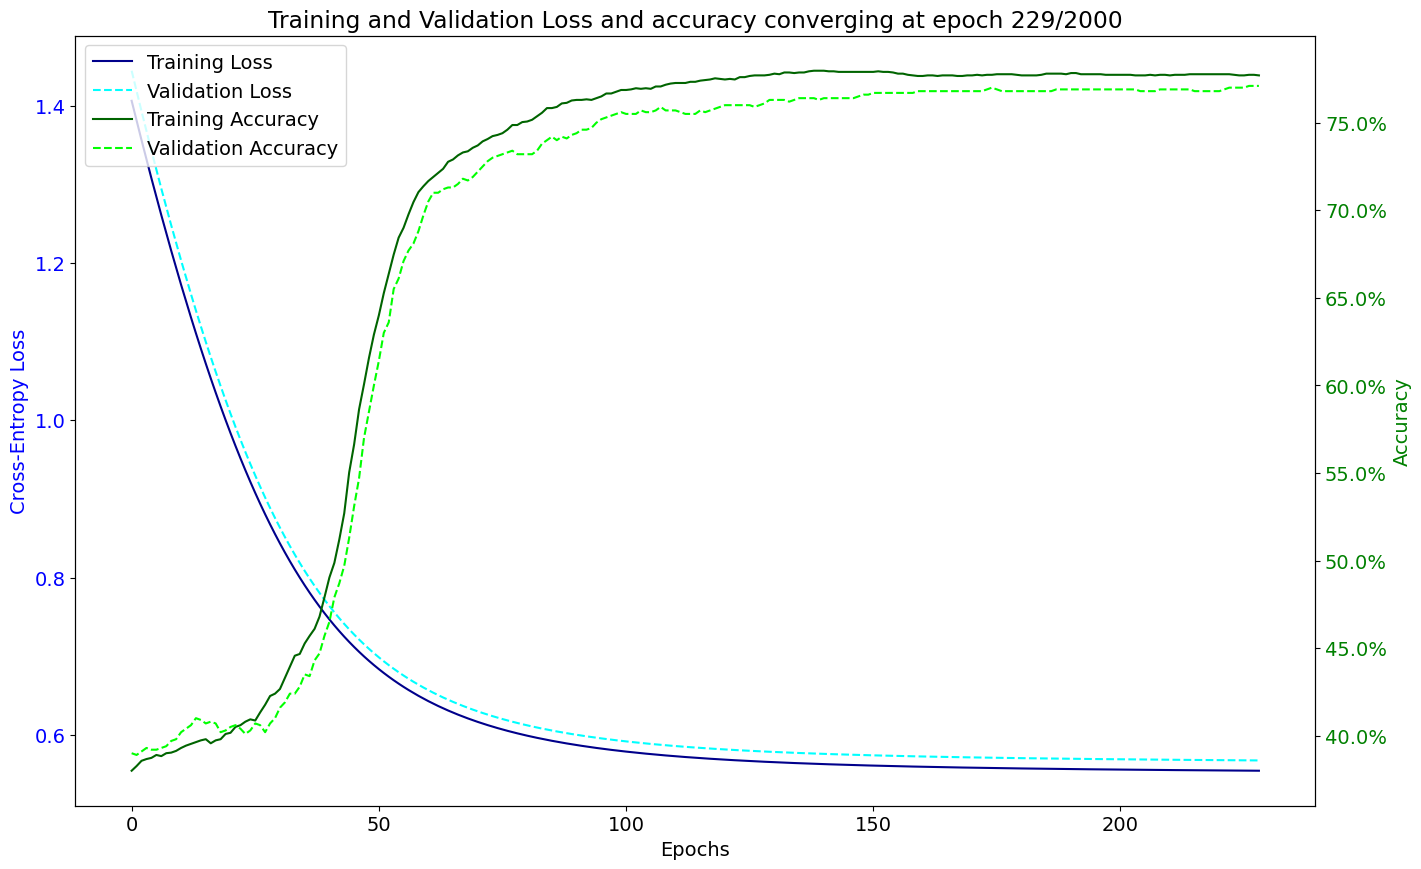

In [26]:
tuner_logreg.plot_search(logx=True, logy=True)
plt.title("Grid search for learning rate and tolerance")
plt.show()

tuner_logreg.plot_regions()

for model in tuner_logreg.best_classifiers:
    model.plot_loss()
    plt.show()

#### Comment:
- The loss and accuracies is identical in shape for the first and second plots. There is a inverse correlation between the ratio of the learning rate the number of epochs and vice versa. 
- We see this as the convergence epoch in the first plot is 4 times the convergence epoch in the second plot.
- Below I have plotted the accuracies side by side to show which are identical, and which are not.

Epoch ratio: 2.69
Inverse tolerance ratio: 2.72
Inverse learning rate ratio: 2.68


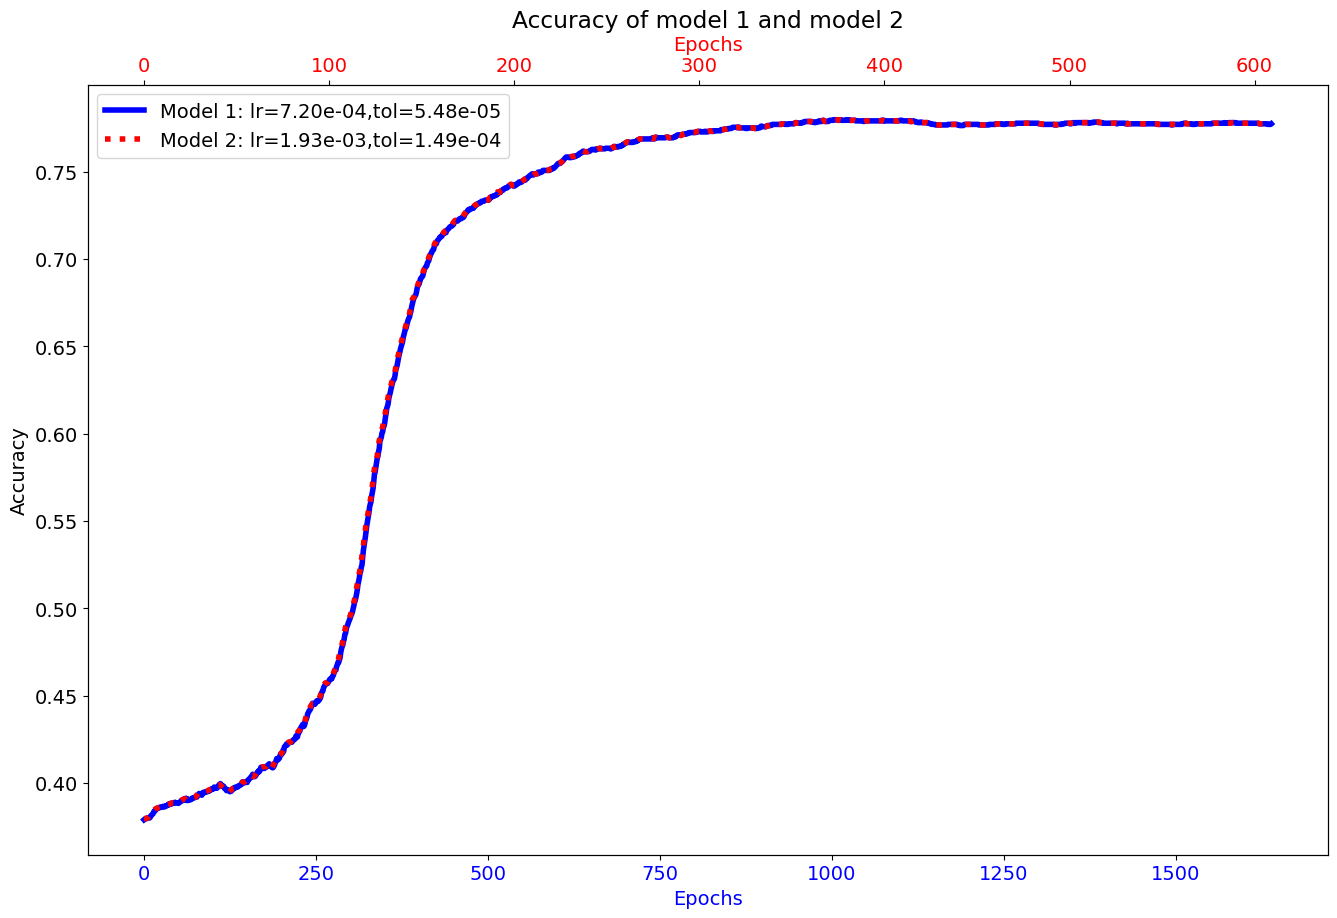

Epoch ratio: 7.16
Inverse tolerance ratio: 7.41
Inverse learning rate ratio: 7.20


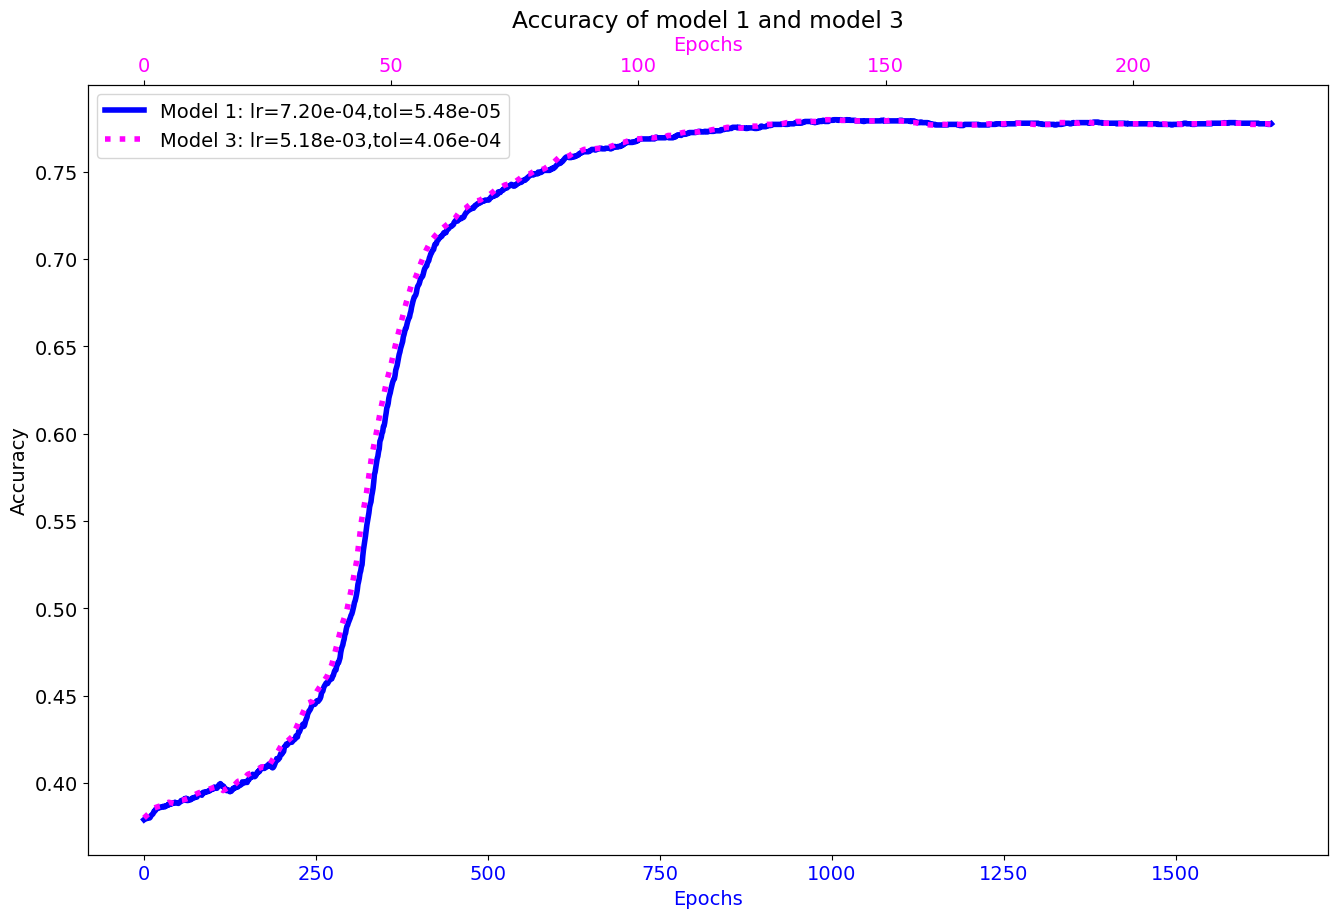

In [27]:
model1 = tuner_logreg.best_classifiers[0]
model2 = tuner_logreg.best_classifiers[1]
model3 = tuner_logreg.best_classifiers[2]

loss1 = np.array(model1.accuracy)
loss2 = np.array(model2.accuracy)
loss3 = np.array(model3.accuracy)

lr1, tol1 = tuner_logreg.best_params['lr'][0], tuner_logreg.best_params['tol'][0]
lr2, tol2 = tuner_logreg.best_params['lr'][1], tuner_logreg.best_params['tol'][1]
lr3, tol3 = tuner_logreg.best_params['lr'][2], tuner_logreg.best_params['tol'][2]


epoch_ratio = len(loss1) / len(loss2)
inv_tol_ratio = tol2 / tol1
inv_lr_ratio = lr2 / lr1

print(f'Epoch ratio: {epoch_ratio:.2f}')
print(f'Inverse tolerance ratio: {inv_tol_ratio:.2f}')
print(f'Inverse learning rate ratio: {inv_lr_ratio:.2f}')


plt.plot(loss1, label=f'Model 1: lr={lr1:.2e},tol={tol1:.2e}', color='blue', linewidth=4)
lines_1, labels_1 = plt.gca().get_legend_handles_labels()
plt.xlabel('Epochs', color='blue')
plt.xticks(color='blue')
plt.ylabel('Accuracy')

plt.twiny()

plt.plot(loss2, label=f'Model 2: lr={lr2:.2e},tol={tol2:.2e}', color='red', linestyle=':', linewidth=4)
plt.xlabel('Epochs', color='red')
plt.xticks(color='red')
lines_2, labels_2 = plt.gca().get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2)
plt.title('Accuracy of model 1 and model 2')
plt.show()


epoch_ratio = len(loss1) / len(loss3)
inv_tol_ratio = tol3 / tol1
inv_lr_ratio = lr3 / lr1

print(f'Epoch ratio: {epoch_ratio:.2f}')
print(f'Inverse tolerance ratio: {inv_tol_ratio:.2f}')
print(f'Inverse learning rate ratio: {inv_lr_ratio:.2f}')

plt.plot(loss1, label=f'Model 1: lr={lr1:.2e},tol={tol1:.2e}', color='blue', linewidth=4)
lines_1, labels_1 = plt.gca().get_legend_handles_labels()
plt.xlabel('Epochs', color='blue')
plt.xticks(color='blue')
plt.ylabel('Accuracy')

plt.twiny()

plt.plot(loss3, label=f'Model 3: lr={lr3:.2e},tol={tol3:.2e}', color='magenta', linestyle=':', linewidth=4)
plt.xlabel('Epochs', color='magenta')
plt.xticks(color='magenta')
lines_3, labels_3 = plt.gca().get_legend_handles_labels()
plt.legend(lines_1 + lines_3, labels_1 + labels_3)
plt.title('Accuracy of model 1 and model 3')
plt.show()

### Scaled

In [28]:
lr_start = -4
lr_stop = -1
n_lr = (lr_stop - lr_start + 1) * 2
learning_rates_logreg = np.logspace(lr_start, lr_stop, n_lr)

tol_start = -6
tol_stop = -1
n_tol = (tol_stop - tol_start + 1) * 4
tolerances = np.logspace(tol_start, tol_stop, n_tol)

# Dynamic variables that will be iterated over in grid search
grid_params = {'tol': tolerances, 'lr': learning_rates_logreg}
# Static variables that will be passed to the fit function
tuner_logreg_scaled = HyperparameterTuner(NumpyLogReg(), grid_params, func_params)

In [29]:
X_train_scaled, X_val_scaled = standard_scaler(X_train, X_val)

tuner_logreg_scaled.search(X_train_scaled, t2_train, X_val_scaled, t2_val)

tol: 100%|██████████| 24/24 [00:14<00:00,  1.63it/s]


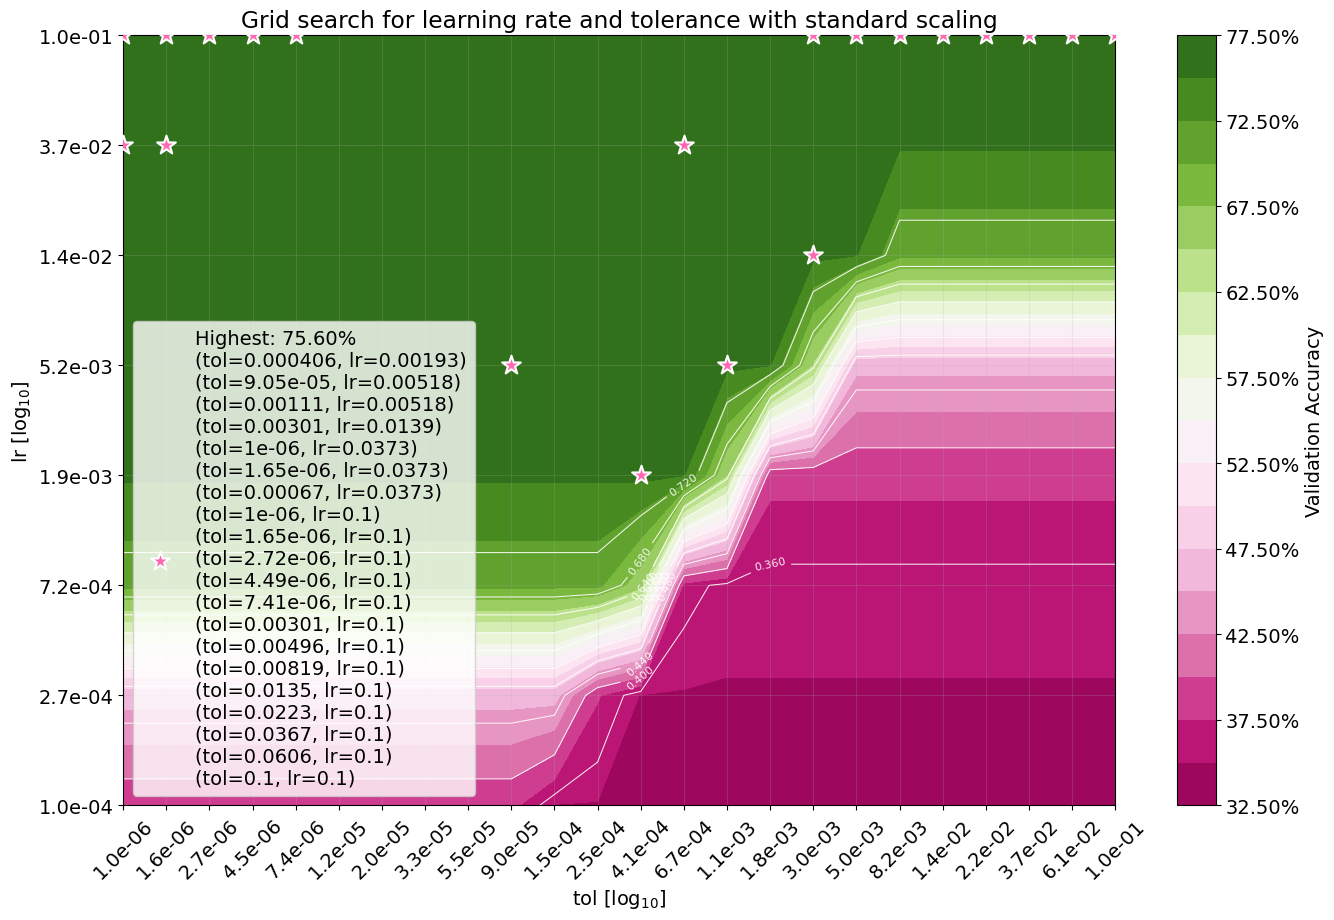

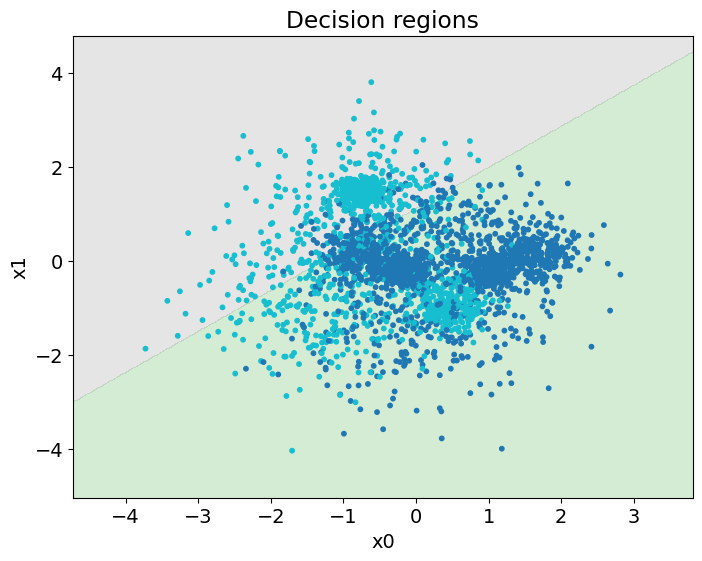

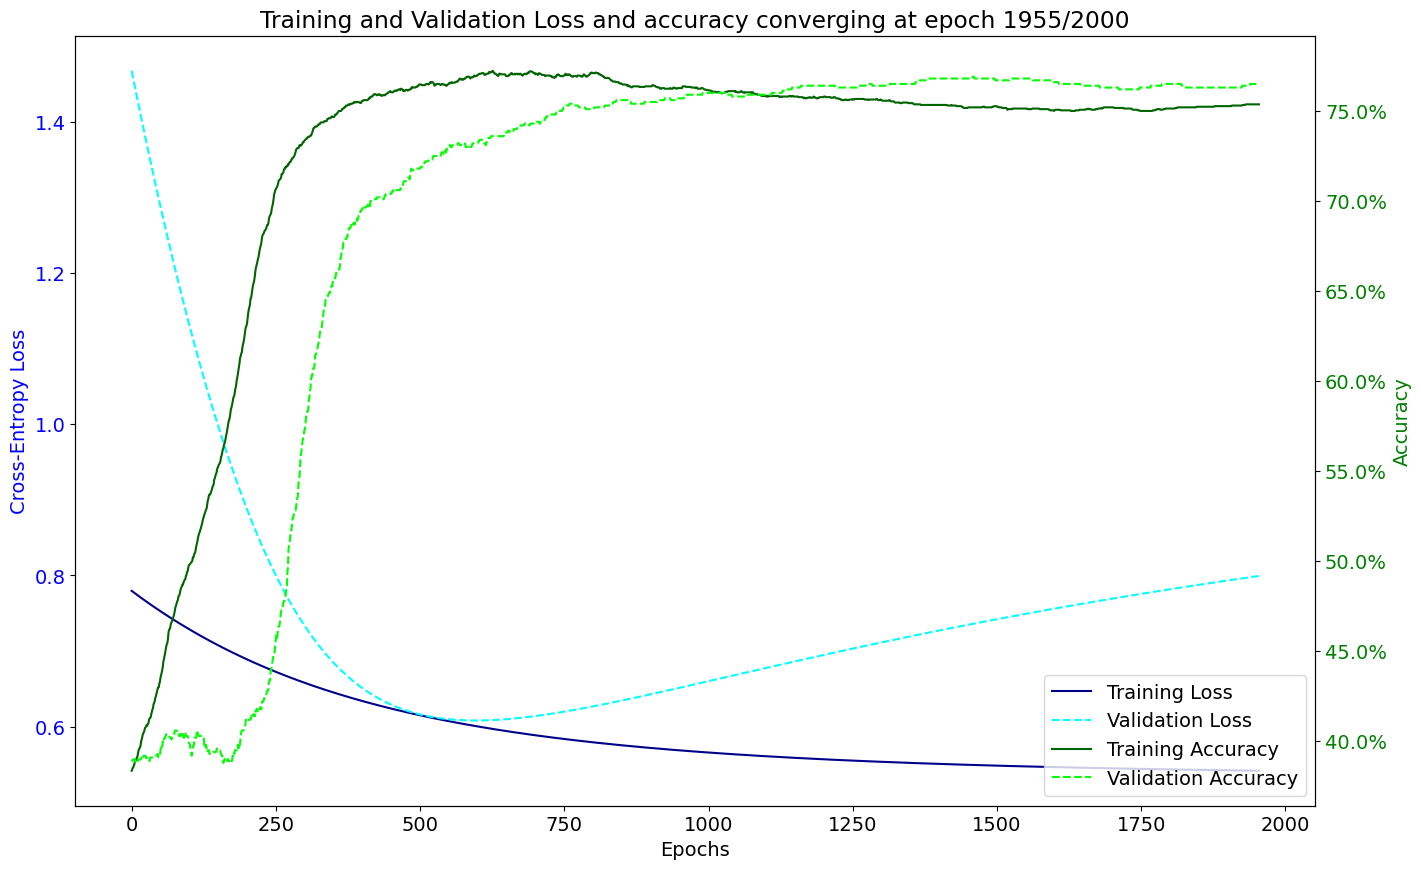

In [30]:
tuner_logreg_scaled.plot_search(logx=True, logy=True)
plt.title("Grid search for learning rate and tolerance with standard scaling")
plt.show()

tuner_logreg_scaled.plot_regions()
plt.show()

tuner_logreg_scaled.plot_loss(1)
plt.show()

### Conclusion
- We get a bit worse results with the scaled, but the accuracy is still high
- In the plot above, we see clear overfitting as the validation loss increases. 
- Many sets of hyperparameters give the best results. Choosing the model resulting in the lowest number of epochs is the best choice.

## Multi-class classifiers
We turn to the task of classifying when there are more than two classes, and the task is to ascribe one class to each input. We will now use the set `(X, t_multi)`.

### Multi-class with logistic regression
We saw in the lectures how a logistic regression classifier can be turned into a multi-class classifier using the one-vs-rest approach. We train one logistic regression classifier for each class. To predict the class of an item, we run all the binary classifiers and collect the probability score from each of them. We assign the class which ascribes the highest probability.

Build such a classifier. Train the resulting classifier on `(X_train, t_multi_train)`, test it on `(X_val, t_multi_val)`, tune the hyper-parameters and report the accuracy.

Also plot the decision boundaries for your best classifier similarly to the plots for the binary case.

In [31]:
class OneVRestLogReg():
    def __init__(self, bias=-1, num_classes=10, seed=420):
        '''
        One-vs-Rest Logistic Regression Classifier.

        This class implements a multi-class classifier using the One-vs-Rest (OvR) approach.
        It trains one binary logistic regression classifier for each class and predicts
        the class with the highest probability for a given input.

        Parameters
        ----------
        bias : int or float, optional
            The bias term to be added to the input features. Default is -1.
        num_classes : int, optional
            The number of classes in the multi-class classification problem. Default is 10.
        seed : int, optional
            Random seed for initializing the binary classifiers. Default is 420.

        Attributes
        ----------
        bias : int or float
            The bias term used in the input features.
        num_classes : int
            The number of classes in the multi-class classification problem.
        seed : int
            Random seed for initializing the binary classifiers.
        classifiers : list of NumpyLogReg
            A list of binary logistic regression classifiers, one for each class.
        '''
        self.bias = bias
        self.num_classes = num_classes
        self.seed = seed 
        
        # Create a list of binary classifiers, one for each class
        self.classifiers = [NumpyLogReg(bias=self.bias, seed=self.seed) for _ in range(num_classes)]
        
    def fit(self, X_train, t_train, lr=0.1, epochs=10, X_val=None, t_val=None, tol=1e-5, n_epochs_no_update=2, min_epochs=0) -> None:
        '''
        Fit the multi-class logistic regression model.

        This method trains one binary logistic regression classifier for each class
        using the One-vs-Rest (OvR) approach. Each classifier is trained to distinguish
        one class from all others.

        Parameters
        ----------
        X_train : np.ndarray
            Training data of shape (N, M), where N is the number of samples and M is the number of features.
        t_train : np.ndarray
            Training target values of shape (N,), where each value is the class label (0 to num_classes-1).
        lr : float, optional
            Learning rate for gradient descent. Default is 0.1.
        epochs : int, optional
            Number of epochs for training. Default is 10.
        X_val : np.ndarray, optional
            Validation data of shape (N_val, M), where N_val is the number of validation samples. Default is None.
        t_val : np.ndarray, optional
            Validation target values of shape (N_val,). Default is None.
        tol : float, optional
            Tolerance for early stopping. Default is 1e-5.
        n_epochs_no_update : int, optional
            Number of epochs to wait for improvement before stopping. Default is 2.
        min_epochs : int, optional
            Minimum number of epochs to run before early stopping. Default is 0.
        '''
        
        for i in range(self.num_classes):
            # Extract only the data relevant to the current class
            t2_train = t_train == i
            t2_val = None
            if t_val is not None:
                t2_val = t_val == i
            
            self.classifiers[i].fit(X_train, t2_train, lr=lr, epochs=epochs, X_val=X_val, t_val=t2_val, tol=tol, n_epochs_no_update=n_epochs_no_update, min_epochs=min_epochs)
            
    
    def predict_probabilites(self, X):
        '''
        Predict the class probabilities for each input sample.
        '''
        predictions = np.zeros((self.num_classes, X.shape[0]))
        for i in range(self.num_classes):
            predictions[i] = self.classifiers[i].predict_probabilites(X)
            
        return predictions
    
    def predict(self, X) -> np.ndarray:
        '''
        Predict the class labels for each input sample.
        This method returns the class with the highest predicted probability.
        '''
        predictions = self.predict_probabilites(X)
        # Take the class with the highest probability
        return np.argmax(predictions, axis=0)
    
    def accuracy(self, X, t):
        ''' 
        Calculate the accuracy of the model on the given data.
        '''
        predictions = self.predict(X)
        return accuracy(predictions, t)

0.324
0.327


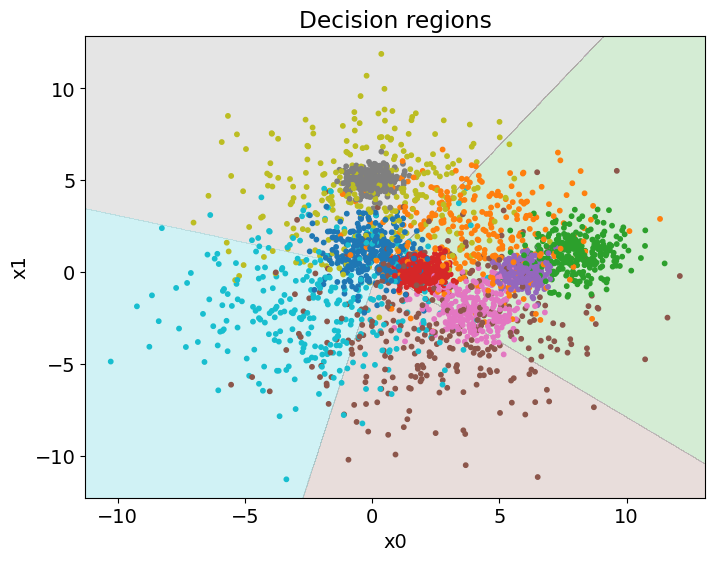

In [32]:
# Test case
multi_class = OneVRestLogReg(bias=1)
multi_class.fit(X_train, t_multi_train, lr=0.001, epochs=1_000,  X_val=X_val, t_val=t_multi_val, tol=1e-5, n_epochs_no_update=10, min_epochs=100)

print(accuracy(multi_class.predict(X_val), t_multi_val))
print(accuracy(multi_class.predict(X_test), t_multi_test))
plot_decision_regions(X_train, t_multi_train, multi_class)

In [33]:
learning_rates = np.logspace(-3, 0, 10)
epochs = np.arange(1000, 2200, 200)
grid_params = {'epochs': epochs, 'lr': learning_rates}
func_params = {'X_val': X_val, 't_val': t_multi_val, 'n_epochs_no_update': 10, 'min_epochs': 100}
tuner_multi_class = HyperparameterTuner(OneVRestLogReg(), grid_params, func_params)
tuner_multi_class.search(X_train, t_multi_train, X_val, t_multi_val)

epochs: 100%|██████████| 6/6 [00:42<00:00,  7.03s/it]


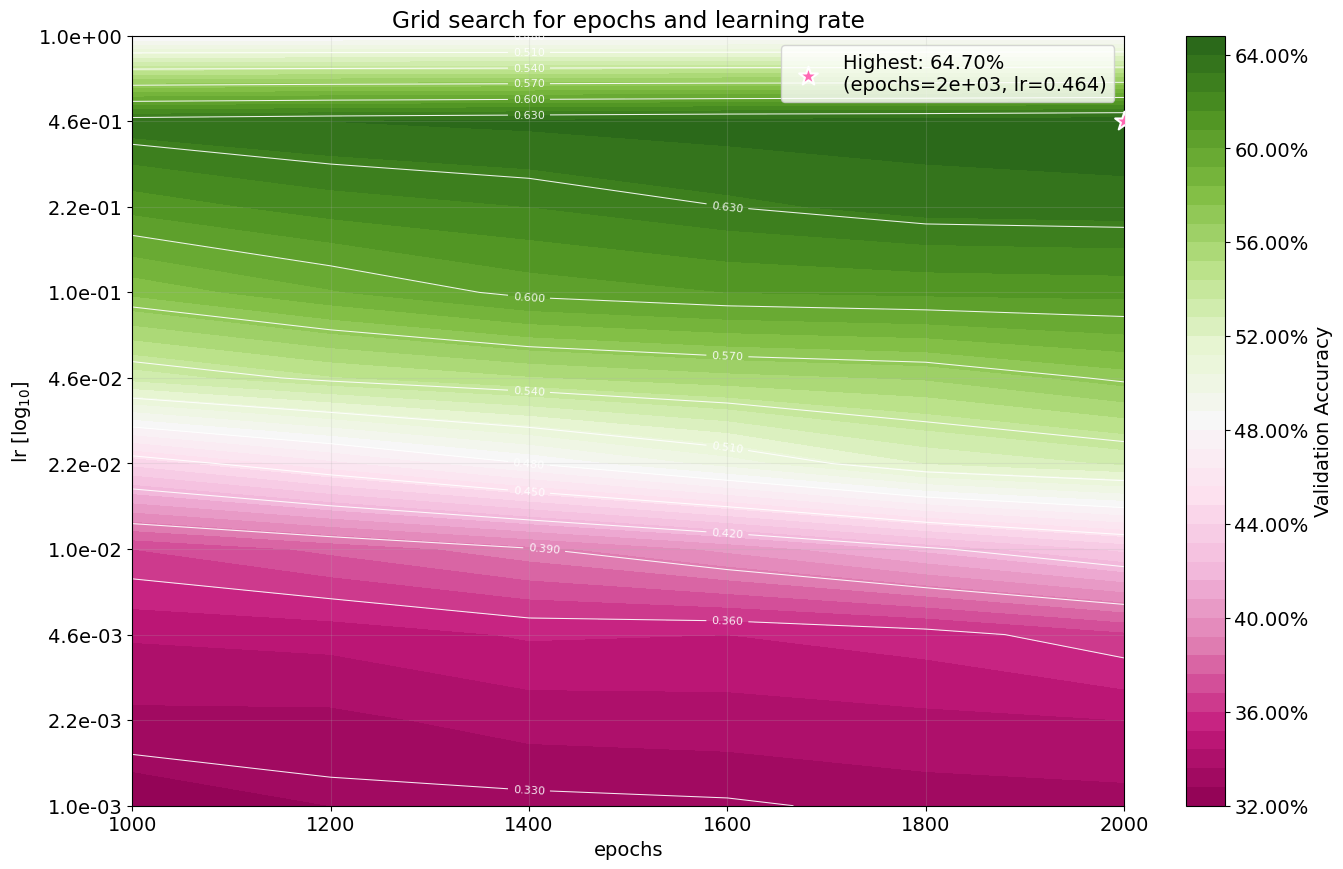

In [34]:
tuner_multi_class.plot_search(logy=True)
plt.title("Grid search for epochs and learning rate")
plt.show()

### For IN4050 students: Multinomial logistic regression
The following part is only mandatory for IN4050 students. IN3050 students are also welcome to make it a try. Everybody has to do the part 2 on multi-layer neural networks. 

In the lectures, we contrasted the one-vs-rest approach with the multinomial logistic regression, also called softmax classifier. Implement also this classifier, tune the parameters, and compare the results to the classifiers above. (Don't expect a large difference on a simple task like this.)

Remember that this classifier uses softmax in the forward phase. For loss, it uses categorical cross-entropy loss. The loss has a somewhat simpler form than in the binary case. To calculate the gradient is a little more complicated. The actual gradient and update rule is simple, however, as long as you have calculated the forward values correctly.

Our classifier is not ideal. But is it because all the 10 classes are equally diffucult to predict?
You should evaluate the multinomial model predictions for each class separately and report your findings.
Please also report whether there is any difference in this respect between the training and the validation sets.

In [ ]:
class MultinomialLogReg(NumpyClassifier):
    def __init__(self, bias=-1, num_classes=10, seed=420):
        '''
        Multinomial Logistic Regression (Softmax) Classifier.
        
        Parameters:
        -----------
        bias : int or float, optional
            The bias term to be added to the input features. Default is -1.
        num_classes : int, optional
            The number of classes in the multi-class classification problem. Default is 10.
        seed : int, optional
            Random seed for initializing weights. Default is 420.
        '''
        self.bias = bias
        self.num_classes = num_classes
        self.seed = seed
        
    def fit(self, X_train, t_train, lr=0.1, epochs=10, X_val=None, t_val=None, tol=1e-5, n_epochs_no_update=2, min_epochs=0):
        '''
        Fit the multinomial logistic regression model.
        
        Parameters:
        -----------
        X_train : np.ndarray
            Training data of shape (N, M), where N is the number of samples and M is the number of features.
        t_train : np.ndarray
            Training target values of shape (N,), where each value is the class label (0 to num_classes-1).
        lr : float, optional
            Learning rate for gradient descent. Default is 0.1.
        epochs : int, optional
            Number of epochs for training. Default is 10.
        X_val : np.ndarray, optional
            Validation data of shape (N_val, M). Default is None.
        t_val : np.ndarray, optional
            Validation target values of shape (N_val,). Default is None.
        tol : float, optional
            Tolerance for early stopping. Default is 1e-5.
        n_epochs_no_update : int, optional
            Number of epochs to wait for improvement before stopping. Default is 2.
        min_epochs : int, optional
            Minimum number of epochs to run before early stopping. Default is 0.
        '''
        self.fit_params = {'lr': lr, 'epochs': epochs, 'tol': tol, 'n_epochs_no_update': n_epochs_no_update, 'min_epochs': min_epochs}
        
        validation = X_val is not None and t_val is not None
        
        if self.bias:
            X_train = add_bias(X_train, self.bias)
            if validation:
                X_val = add_bias(X_val, self.bias)
        
        (N, M) = X_train.shape
        
        # Convert targets to one-hot encoding
        t_train_one_hot = self._to_one_hot(t_train)
        if validation:
            t_val_one_hot = self._to_one_hot(t_val)
        
        np.random.seed(self.seed)
        self.weights = np.random.randn(M, self.num_classes) * 0.01
        
        self.loss = []
        self.accuracy = []
        self.val_loss = []
        self.val_accuracy = []
        self.convergence_epoch = None
        
        for e in range(epochs):
            if e > min_epochs:
                loss_avg = self.loss[e-n_epochs_no_update]
                improvement = loss_avg - self.loss[-1]
                if improvement < tol:
                    self.convergence_epoch = e
                    break
            
            # Forward pass to get probabilities
            probs = self.softmax(X_train @ self.weights)
            
            gradient = X_train.T @ (probs - t_train_one_hot) / N
            
            self.weights -= lr * gradient
            
            # Calculate and store loss and accuracy
            self.loss.append(self.cross_entropy_loss(X_train, t_train_one_hot))
            self.accuracy.append(accuracy(self.predict(X_train), t_train))
            
            if validation:
                self.val_loss.append(self.cross_entropy_loss(X_val, t_val_one_hot))
                self.val_accuracy.append(accuracy(self.predict(X_val), t_val))
        
        if self.convergence_epoch is None:
            self.convergence_epoch = epochs
    
    def softmax(self, z):
        '''
        Compute the softmax of the input.
        
        Parameters:
        -----------
        z : np.ndarray
            Input array of shape (N, C), where N is the number of samples and C is the number of classes.
        
        Returns:
        --------
        probs : np.ndarray
            Softmax probabilities of shape (N, C).
        '''
        # For numerical stability, subtract the maximum value from each row
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def _to_one_hot(self, t):
        '''
        Convert labels to one-hot encoding.
        
        Parameters:
        -----------
        t : np.ndarray
            Array of labels of shape (N,).
        
        Returns:
        --------
        one_hot : np.ndarray
            One-hot encoded labels of shape (N, num_classes).
        '''
        N = t.shape[0]
        one_hot = np.zeros((N, self.num_classes))
        one_hot[np.arange(N), t] = 1
        return one_hot
    
    def predict_probabilities(self, X):
        '''
        Predict the class probabilities for each input sample.
        
        Parameters:
        -----------
        X : np.ndarray
            Input data of shape (N, M).
        
        Returns:
        --------
        probs : np.ndarray
            Class probabilities of shape (N, num_classes).
        '''
        is_dimensions_one_off = X.shape[1] == self.weights.shape[0] - 1
        if self.bias and is_dimensions_one_off:
            X = add_bias(X, self.bias)
        
        return self.softmax(X @ self.weights)
    
    def predict(self, X):
        '''
        Predict the class labels for each input sample.
        
        Parameters:
        -----------
        X : np.ndarray
            Input data of shape (N, M).
        
        Returns:
        --------
        predictions : np.ndarray
            Predicted class labels of shape (N,).
        '''
        probs = self.predict_probabilities(X)
        return np.argmax(probs, axis=1)
    
    
    def cross_entropy_loss(self, X, t_one_hot):
        '''
        Compute the cross-entropy loss.
        
        Parameters:
        -----------
        X : np.ndarray
            Input data of shape (N, M).
        t_one_hot : np.ndarray
            One-hot encoded target values of shape (N, num_classes).
        
        Returns:
        --------
        loss : float
            The cross-entropy loss.
        '''
        probs = self.predict_probabilities(X)
        # Add small epsilon to avoid log(0)
        epsilon = 1e-15
        log_probs = np.log(probs + epsilon)
        return -np.mean(np.sum(t_one_hot * log_probs, axis=1))
    
    def plot_loss(self):
        '''
        Plot the loss and accuracy during training.
        
        Returns:
        --------
        fig : matplotlib.figure.Figure
            The figure object.
        '''
        
        plt.plot(self.loss, label='Training Loss', color='darkblue')
        if self.val_loss:
            plt.plot(self.val_loss, label='Validation Loss', color='aqua', linestyle='--')
        lines_loss, labels_loss = plt.gca().get_legend_handles_labels()
        plt.ylabel('Cross-Entropy Loss', color='blue')
        plt.yticks(color='blue')
        plt.xlabel('Epochs')
        
        plt.twinx()
        
        plt.plot(self.accuracy, label='Training Accuracy', color='darkgreen')
        if self.val_accuracy:
            plt.plot(self.val_accuracy, label='Validation Accuracy', color='lime', linestyle='--')
        lines_acc, labels_acc = plt.gca().get_legend_handles_labels()
        plt.ylabel('Accuracy', color='green')
        plt.yticks(color='green')
        percentage_formatter = lambda x, _: f'{x:.1%}'
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(percentage_formatter))
        
        plt.title(f'Training and Validation Loss and Accuracy (Converged at epoch {self.convergence_epoch}/{self.fit_params["epochs"]})')
        plt.legend(lines_loss + lines_acc, labels_loss + labels_acc)
        
        fig = plt.gcf()
        return fig
    
    def evaluate_per_class(self, X, t):
        '''
        Evaluate the model performance for each class separately.
        
        Parameters:
        -----------
        X : np.ndarray
            Input data of shape (N, M).
        t : np.ndarray
            Target values of shape (N,).
        
        Returns:
        --------
        metrics : dict
            Dictionary containing accuracy, precision and recall for each class.
        '''
        y_pred = self.predict(X)
        metrics = {}
        
        for class_idx in range(self.num_classes):
            class_mask = (t == class_idx)
            if np.sum(class_mask) > 0:  # If there are samples of this class
                # Accuracy for this class
                correct = (y_pred[class_mask] == class_idx)
                accuracy_class = np.mean(correct)
                
                # Precision for this class
                predicted_as_class = (y_pred == class_idx)
                if np.sum(predicted_as_class) > 0:
                    precision = np.sum((t[predicted_as_class] == class_idx)) / np.sum(predicted_as_class)
                else:
                    precision = 0
                
                # Recall for this class
                if np.sum(class_mask) > 0:
                    recall = np.sum((y_pred[class_mask] == class_idx)) / np.sum(class_mask)
                else:
                    recall = 0
                
                metrics[class_idx] = {
                    'accuracy': accuracy_class,
                    'precision': precision,
                    'recall': recall,
                    'samples': np.sum(class_mask)
                }
        
        return metrics

In [36]:
# Setup grid search parameters for MultinomialLogReg
lr_start = -2
lr_stop = 0
n_lr = 8  # Number of learning rates to try
learning_rates = np.logspace(lr_start, lr_stop, n_lr)

epochs = np.arange(200, 2200, 200)

grid_params = {'epochs': epochs, 'lr': learning_rates}
func_params = {'tol': 1e-3, 'X_val': X_val, 't_val': t_multi_val, 'n_epochs_no_update': 10, 'min_epochs': 100}


tuner_multinomial = HyperparameterTuner(MultinomialLogReg(), grid_params, func_params)

In [37]:
tuner_multinomial.search(X_train, t_multi_train, X_val, t_multi_val)

epochs: 100%|██████████| 10/10 [00:29<00:00,  2.99s/it]


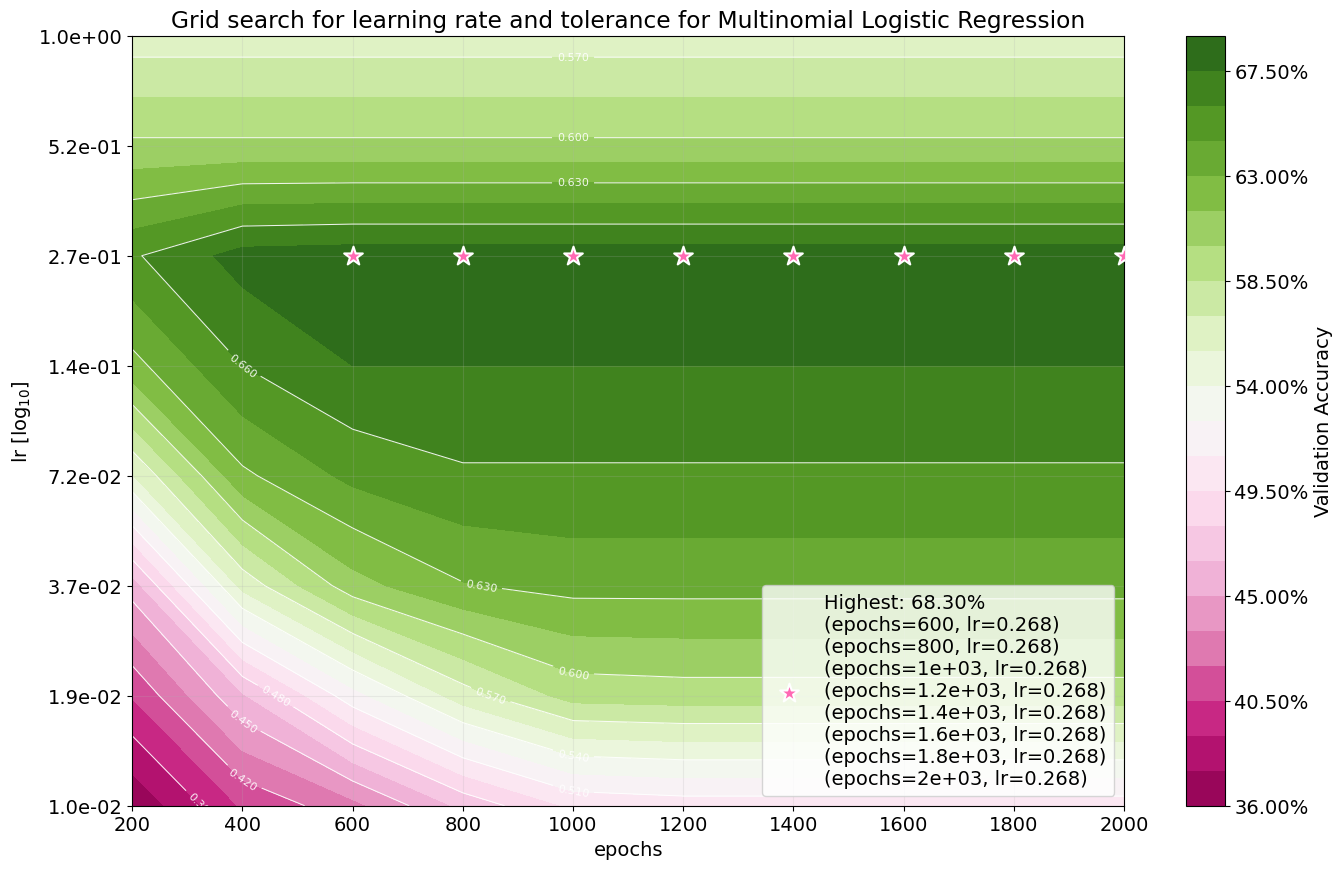

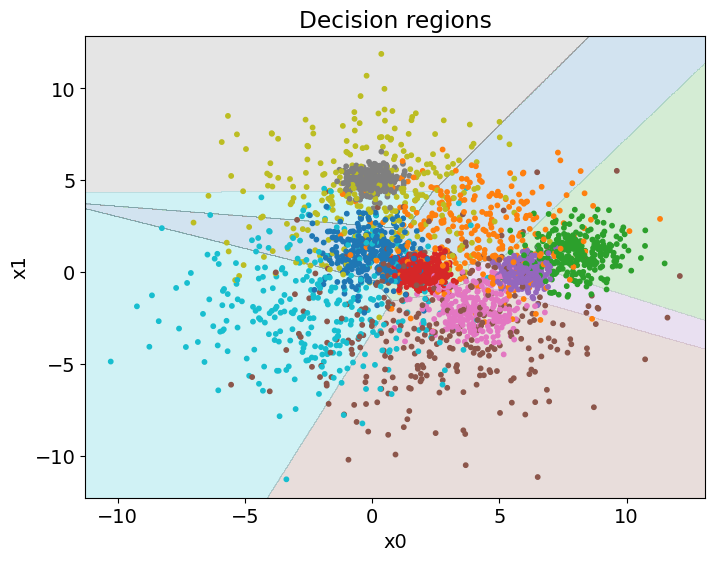

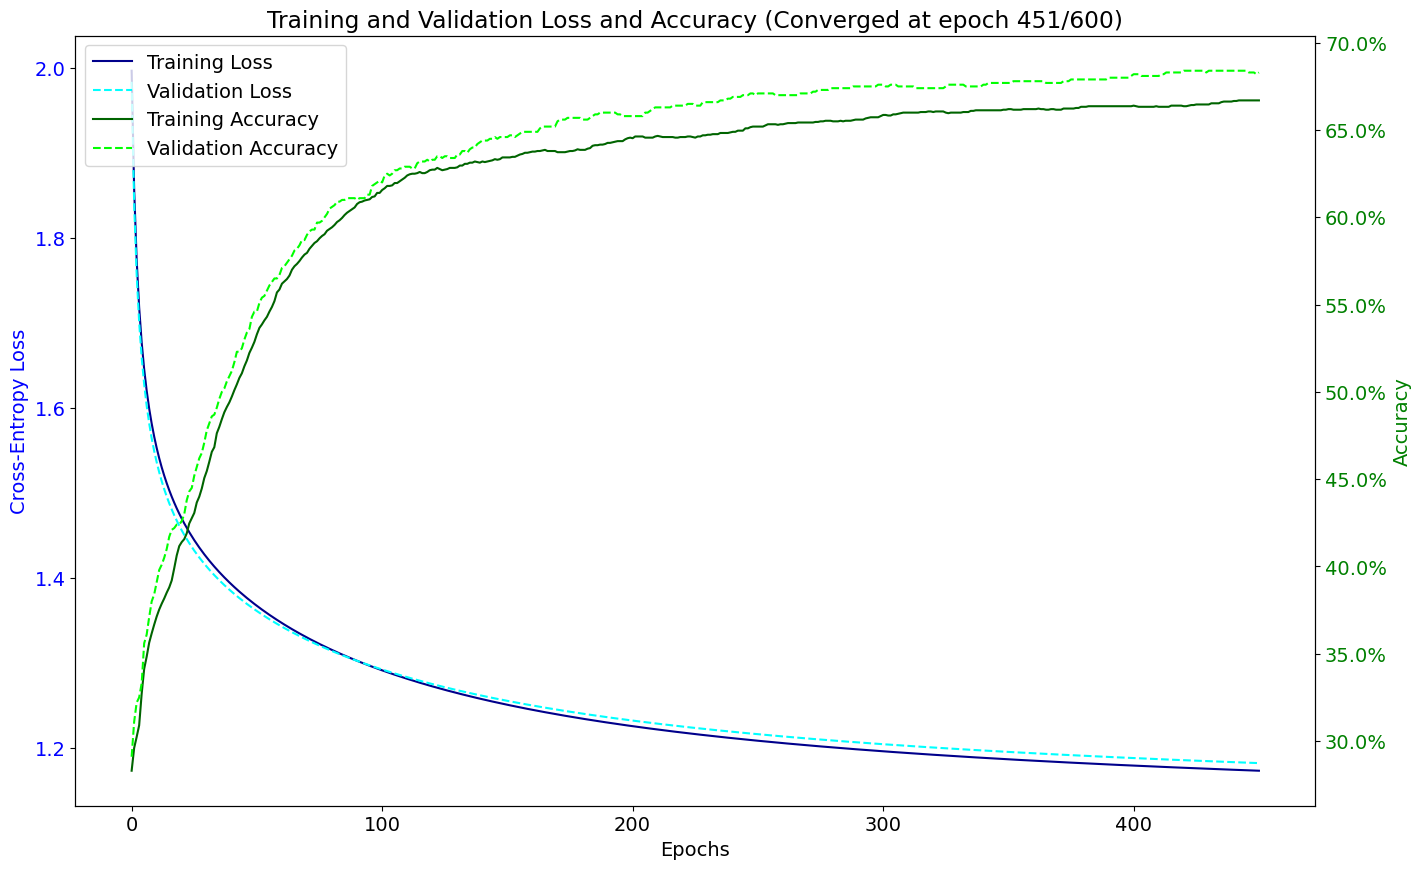

In [38]:
tuner_multinomial.plot_search(logy=True)
plt.title("Grid search for learning rate and tolerance for Multinomial Logistic Regression")
plt.show()

tuner_multinomial.plot_regions()
plt.show()

tuner_multinomial.best_classifiers[0].plot_loss()
plt.show()

In [39]:
best_classifier = tuner_multinomial.best_classifiers[0]
train_metrics = best_classifier.evaluate_per_class(X_train, t_multi_train)
val_metrics = best_classifier.evaluate_per_class(X_val, t_multi_val)

table = [["Class", "Train Acc.", "Val Acc.", "Train Precision", "Val Precision", "Train Recall", "Val Recall", "Train Samples", "Val Samples"]]

for class_idx in range(best_classifier.num_classes):
    train_acc = train_metrics[class_idx]['accuracy']
    train_precision = train_metrics[class_idx]['precision']
    train_recall = train_metrics[class_idx]['recall']
    train_samples = train_metrics[class_idx]['samples']
    val_acc = val_metrics[class_idx]['accuracy']   
    val_precision = val_metrics[class_idx]['precision']
    val_recall = val_metrics[class_idx]['recall']
    val_samples = val_metrics[class_idx]['samples']
    
    table.append([class_idx, f"{train_acc:.2%}", f"{val_acc:.2%}", f"{train_precision:.2%}", f"{val_precision:.2%}", f"{train_recall:.2%}", f"{val_recall:.2%}", train_samples, val_samples])

print(tabulate(table, headers="firstrow", tablefmt="grid"))

+---------+--------------+------------+-------------------+-----------------+----------------+--------------+-----------------+---------------+
|   Class | Train Acc.   | Val Acc.   | Train Precision   | Val Precision   | Train Recall   | Val Recall   |   Train Samples |   Val Samples |
+=========+==============+============+===================+=================+================+==============+=================+===============+
|       0 | 70.87%       | 69.89%     | 64.99%            | 67.01%          | 70.87%         | 69.89%       |             309 |            93 |
+---------+--------------+------------+-------------------+-----------------+----------------+--------------+-----------------+---------------+
|       1 | 52.35%       | 57.58%     | 71.23%            | 69.51%          | 52.35%         | 57.58%       |             298 |            99 |
+---------+--------------+------------+-------------------+-----------------+----------------+--------------+-----------------+---------

### Conclusion:
- The accuracy is very low at around 60%.
- The decision boundaries are reasonable, but the points are not well separated. This might be as good as it gets using a linear classifier on this dataset.
- There is a clear preference for more epochs, but it takes a long time to train. 
- The logistic regression classifier performs slightly better at around 68% accuracy. This varied from class to class from 20% to 96%.

# Part 2 Multi-layer neural networks

## A first non-linear classifier

The following code is a simple implementation of a multi-layer perceptron or feed-forward neural network.
For now, it is quite restricted.
There is only one hidden layer with 6 neurons.
It can only handle binary classification.
In addition, it uses a simple final layer similar to the linear regression classifier above.
One way to look at it is what happens when we add a hidden layer to the linear regression classifier.

The MLP class below misses the implementation of the `forward()` function. Your first task is to implement it. 

Remember that in the forward pass, we "feed" the input to the model, the model processes it and produces the output. The function should make use of the logistic activation function and bias.

In [40]:
# First, we define the logistic function and its derivative:
def logistic(x):
    return 1/(1+np.exp(-x))

def logistic_diff(y):
    return y * (1 - y)

In [41]:
class MLPBinaryLinRegClass(NumpyClassifier):
    """A multi-layer neural network with one hidden layer"""
    
    def __init__(self, bias=-1, dim_hidden = 6, seed=420):
        """Intialize the hyperparameters"""
        self.bias = bias
        self.dim_hidden = dim_hidden
        self.activ = logistic
        self.activ_diff = logistic_diff
        self.seed = seed
        
    def forward(self, X):
        """
        Perform one forward step. 
        Return a pair consisting of the outputs of the hidden_layer
        and the outputs on the final layer
        """
        # Compute the outputs of the hidden layer
        hidden_inputs = X @ self.weights1
        hidden_outs = add_bias(self.activ(hidden_inputs), self.bias)
        
        # Compute the outputs of the final layer
        final_inputs = hidden_outs @ self.weights2
        outputs = self.activ(final_inputs)
        
        return hidden_outs, outputs
    
    def fit(self, X_train, t_train, lr=0.001, epochs = 100):
        """Initialize the weights. Train *epochs* many epochs.
        
        X_train is a NxM matrix, N data points, M features
        t_train is a vector of length N of targets values for the training data, 
        where the values are 0 or 1.
        lr is the learning rate
        """
        self.lr = lr
        
        # Turn t_train into a column vector, a N*1 matrix:
        T_train = t_train.reshape(-1,1)
            
        dim_in = X_train.shape[1] 
        dim_out = T_train.shape[1]
        
        # Initialize the weights
        np.random.seed(self.seed)
        self.weights1 = (np.random.rand(
            dim_in + 1, 
            self.dim_hidden) * 2 - 1)/np.sqrt(dim_in)
        self.weights2 = (np.random.rand(
            self.dim_hidden+1, 
            dim_out) * 2 - 1)/np.sqrt(self.dim_hidden)
        X_train_bias = add_bias(X_train, self.bias)
        
        for e in range(epochs):
            hidden_outs, outputs = self.forward(X_train_bias)
            
            out_deltas = (outputs - T_train)
            
            hiddenout_diffs = out_deltas @ self.weights2.T
            hiddenact_deltas = (hiddenout_diffs[:, 1:] * 
                                self.activ_diff(hidden_outs[:, 1:]))  

            self.weights2 -= self.lr * hidden_outs.T @ out_deltas
            self.weights1 -= self.lr * X_train_bias.T @ hiddenact_deltas 
            
    
    def predict(self, X):
        """Predict the class for the members of X"""
        Z = add_bias(X, self.bias)
        forw = self.forward(Z)[1]
        score= forw[:, 0]
        return (score > 0.5)

When implemented, this model can be used to make a non-linear classifier for the set `(X, t2)`. Experiment with settings for learning rate and epochs and see how good results you can get. 
Report results for various settings. Be prepared to train for a long time (but you can control it via the number of epochs and hidden size). 

Plot the training set together with the decision regions as in Part I.

Train accuracy: 80.63%
Validation accuracy: 79.80%


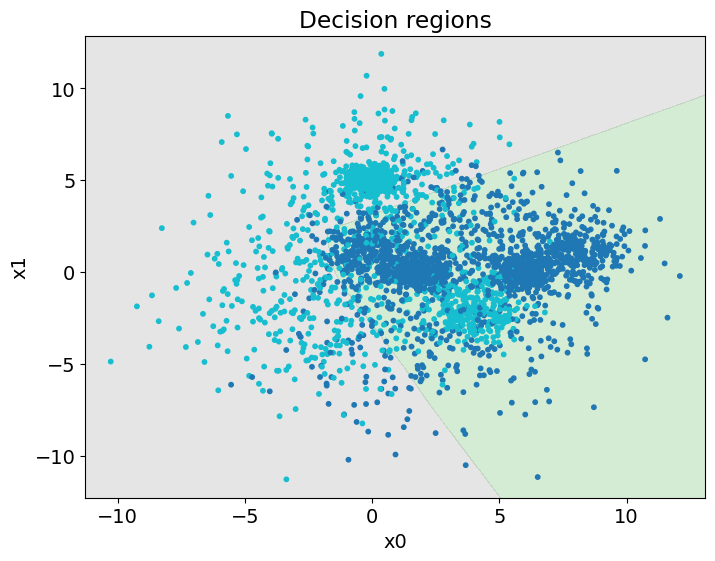

In [42]:
# Test the MLPBinaryLinRegClass
mlp = MLPBinaryLinRegClass()
mlp.fit(X_train, t2_train, lr=0.01, epochs=1000)
print(f'Train accuracy: {accuracy(mlp.predict(X_train), t2_train):.2%}')
print(f'Validation accuracy: {accuracy(mlp.predict(X_val), t2_val):.2%}')
plot_decision_regions(X_train, t2_train, mlp)
plt.show()


In [43]:
learning_rates = np.logspace(-4, -1, 10)
epochs = np.arange(200, 1700, 200)
grid_params = {'epochs': epochs, 'lr': learning_rates}
func_params = {'tol': 1e-3}

tuner_mlp = HyperparameterTuner(MLPBinaryLinRegClass(), grid_params)

In [44]:
tuner_mlp.search(X_train, t2_train, X_val, t2_val)

epochs:   0%|          | 0/8 [00:00<?, ?it/s]/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
epochs:  12%|█▎        | 1/8 [00:00<00:02,  2.88it/s]/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
epochs:  25%|██▌       | 2/8 [00:00<00:02,  2.10it/s]/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
epochs:  38%|███▊      | 3/8 [00:01<00:03,  1.53it/s]/tmp/ipykernel_1977902/702837997.py:3: RuntimeWar

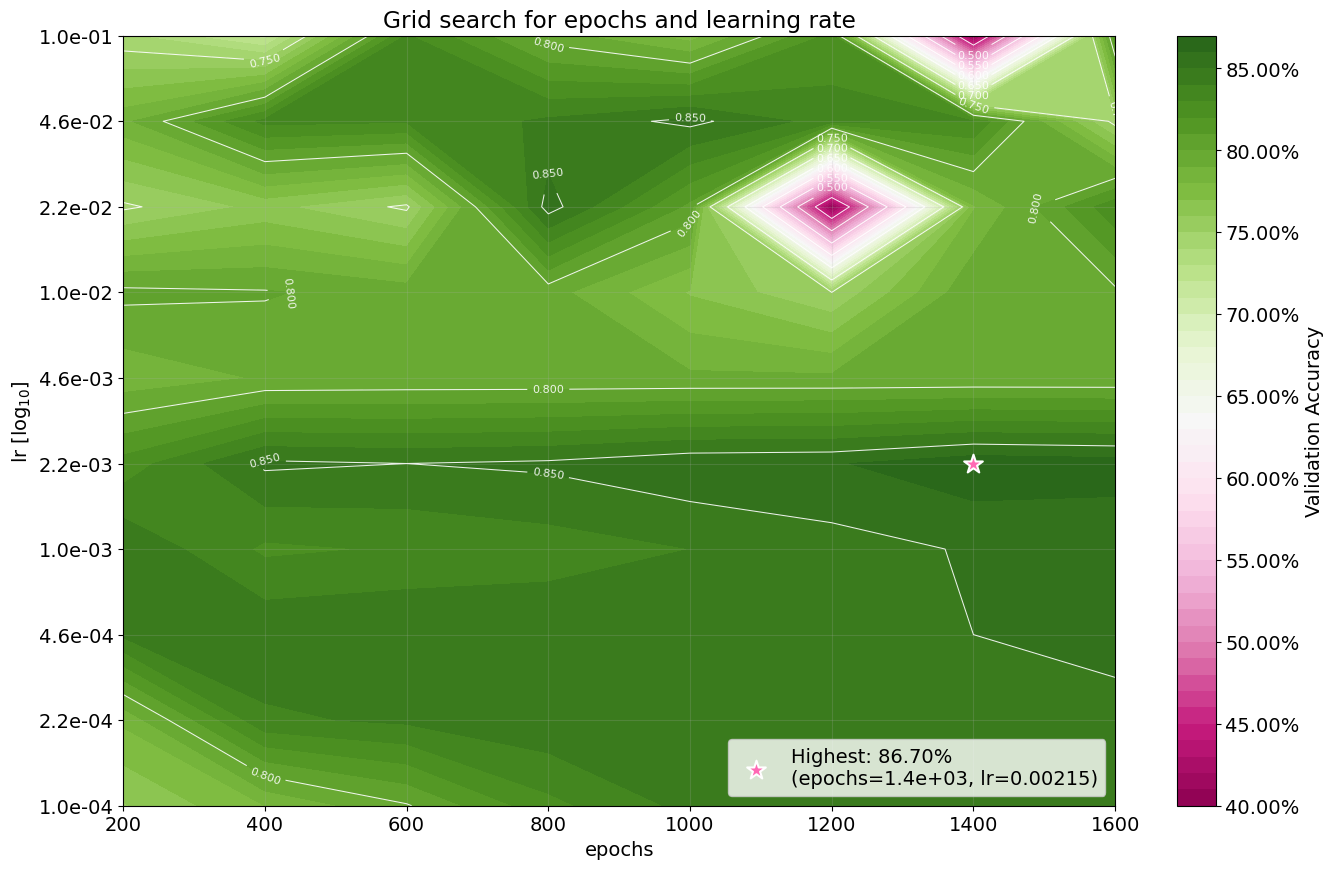

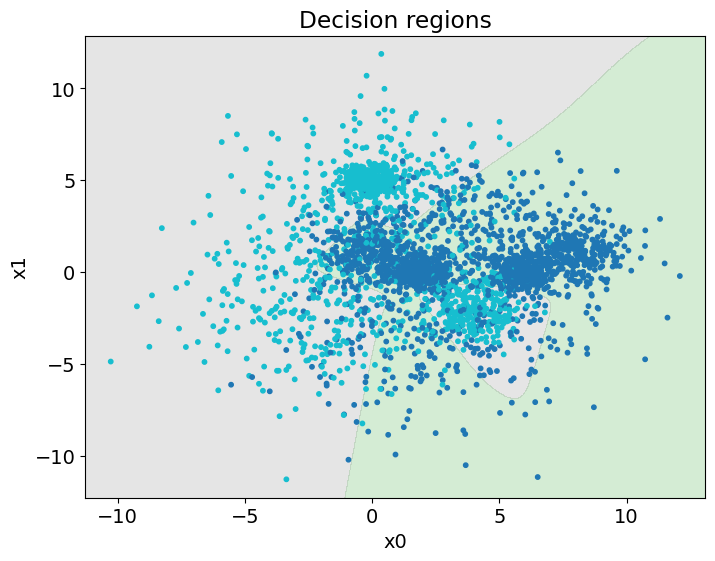

In [45]:
tuner_mlp.plot_search(logy=True)
plt.title("Grid search for epochs and learning rate")
plt.show()

tuner_mlp.plot_regions()

# Improving the MLP classifier
You should now make changes to the classifier similarly to what you did with the logistic regression classifier in part 1.

a) In addition to the `predict()` method, which predicts a class for the data, include the `predict_probabilities()` method which predict the probability of the data belonging to the positive class. The training should be based on these values, as with logistic regression.

b) Calculate the loss and the accuracy after each epoch and store them for inspection after training.

c) Extend the `fit()` method with optional arguments for a validation set `(X_val, t_val)`. If a validation set is included in the call to `fit()`, calculate the loss and the accuracy for the validation set after each epoch.

d) Extend the `fit()` method with two keyword arguments, `tol` (tolerance) and `n_epochs_no_update` and stop training when the loss has not improved for more than `tol` after `n_epochs_no_update`. A possible default value for `n_epochs_no_update` is 2. Add an attribute to the classifier which tells us after fitting how many epochs it was trained on.

e) Tune the hyper-parameters: `lr`, `tol` and `dim-hidden` (size of the hidden layer).
Also, consider the effect of scaling the data.

f) After a succesful training with the best setting for the hyper-parameters, plot both training loss and validation loss as functions of the number of epochs in one figure, and both training and validation accuracies as functions of the number of epochs in another figure. Comment on what you see.

g) The MLP algorithm contains an element of non-determinism. Hence, train the classifier 3 times with the optimal hyper-parameters and report the mean and standard deviation of the accuracies over the 3 runs.

In [46]:
class MLPBinaryLinRegClassImproved(NumpyClassifier):
    """An improved multi-layer neural network with one hidden layer"""
    
    def __init__(self, bias=-1, dim_hidden = 6, seed=420):
        """Intialize the hyperparameters"""
        self.bias = bias
        self.dim_hidden = dim_hidden
        self.activ = logistic
        self.activ_diff = logistic_diff
        self.seed = seed
        
    def forward(self, X):
        """
        Perform one forward step. 
        Return a pair consisting of the outputs of the hidden_layer
        and the outputs on the final layer
        """
        # Compute the outputs of the hidden layer
        hidden_inputs = X @ self.weights1
        hidden_outs = add_bias(self.activ(hidden_inputs), self.bias)
        
        # Compute the outputs of the final layer
        final_inputs = hidden_outs @ self.weights2
        outputs = self.activ(final_inputs)
        
        return hidden_outs, outputs
    
    def fit(self, X_train, t_train, lr=0.1, epochs=10, X_val=None, t_val=None, tol=1e-5, n_epochs_no_update=2, min_epochs=0, dim_hidden=None):
        '''
        Fit the model.
        
        Parameters:
        -----------
        X_train : np.ndarray
            Training data of shape (N, M), where N is the number of samples and M is the number of features.
        t_train : np.ndarray
            Training target values of shape (N,), where each value is the class label (0 to num_classes-1).
        lr : float, optional
            Learning rate for gradient descent. Default is 0.1.
        epochs : int, optional
            Number of epochs for training. Default is 10.
        X_val : np.ndarray, optional
            Validation data of shape (N_val, M). Default is None.
        t_val : np.ndarray, optional
            Validation target values of shape (N_val,). Default is None.
        tol : float, optional
            Tolerance for early stopping. Default is 1e-5.
        n_epochs_no_update : int, optional
            Number of epochs to wait for improvement before stopping. Default is 2.
        min_epochs : int, optional
            Minimum number of epochs to run before early stopping. Default is 0.
        '''
        
        self.fit_params = {'lr': lr, 'epochs': epochs, 'tol': tol, 'n_epochs_no_update': n_epochs_no_update, 'min_epochs': min_epochs}
        
        validation = X_val is not None and t_val is not None
        
        # Turn t_train into a column vector, a N*1 matrix:
        T_train = t_train.reshape(-1,1)
            
        dim_in = X_train.shape[1] 
        dim_out = T_train.shape[1]
        
        # Initialize the weights
        if dim_hidden is not None:
            self.dim_hidden = dim_hidden
            self.fit_params['dim_hidden'] = dim_hidden
            
        np.random.seed(self.seed)
        self.weights1 = (np.random.rand(dim_in + 1, self.dim_hidden) * 2 - 1)/np.sqrt(dim_in)
        self.weights2 = (np.random.rand(self.dim_hidden+1, dim_out) * 2 - 1)/np.sqrt(self.dim_hidden)
        X_train_bias = add_bias(X_train, self.bias)
        if validation:
            X_val = add_bias(X_val, self.bias)
        
        
        self.loss = []
        self.accuracy = []
        self.val_loss = []
        self.val_accuracy = []
        self.convergence_epoch = None
        for e in range(epochs):
            if e > min_epochs:
                loss_avg = self.loss[e-n_epochs_no_update]
                improvement = loss_avg - self.loss[-1]
                if improvement < tol:
                    self.convergence_epoch = e
                    break
            hidden_outs, outputs = self.forward(X_train_bias)
            
            out_deltas = (outputs - T_train)
            
            hiddenout_diffs = out_deltas @ self.weights2.T
            hiddenact_deltas = (hiddenout_diffs[:, 1:] * 
                                self.activ_diff(hidden_outs[:, 1:]))  

            self.weights2 -= lr * hidden_outs.T @ out_deltas
            self.weights1 -= lr * X_train_bias.T @ hiddenact_deltas 
            
            self.loss.append(log_loss(t_train, self.predict(X_train)))
            self.accuracy.append(accuracy(self.predict(X_train), t_train))
            if validation:
                self.val_loss.append(log_loss(t_val, self.predict(X_val)))
                self.val_accuracy.append(accuracy(self.predict(X_val), t_val))
        
        if self.convergence_epoch is None:
            self.convergence_epoch = epochs
    
    
    def predict_probabilites(self, X):
        """Predict the class for the members of X"""
        if X.shape[1] == self.weights1.shape[0] - 1:
            X = add_bias(X, self.bias)
            
        forw = self.forward(X)[1]
        score= forw[:, 0]
        return score
    
    def predict(self, X):
        """Predict the class for the members of X"""
        return self.predict_probabilites(X) > 0.5
    
    
    def plot_loss(self):
        '''
        Plot the loss and accuracy during training.
        
        Returns:
        --------
        fig : matplotlib.figure.Figure
            The figure object.
        '''
        
        plt.plot(self.loss, label='Training Loss', color='darkblue')
        if self.val_loss:
            plt.plot(self.val_loss, label='Validation Loss', color='aqua', linestyle='--')
        lines_loss, labels_loss = plt.gca().get_legend_handles_labels()
        plt.ylabel('Cross-Entropy Loss', color='blue')
        plt.yticks(color='blue')
        plt.xlabel('Epochs')
        
        plt.twinx()
        
        plt.plot(self.accuracy, label='Training Accuracy', color='darkgreen')
        if self.val_accuracy:
            plt.plot(self.val_accuracy, label='Validation Accuracy', color='lime', linestyle='--')
        lines_acc, labels_acc = plt.gca().get_legend_handles_labels()
        plt.ylabel('Accuracy', color='green')
        plt.yticks(color='green')
        percentage_formatter = lambda x, _: f'{x:.1%}'
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(percentage_formatter))
        
        plt.title(f'Training and Validation Loss and Accuracy (Converged at epoch {self.convergence_epoch}/{self.fit_params["epochs"]})')
        plt.legend(lines_loss + lines_acc, labels_loss + labels_acc)
        
        fig = plt.gcf()
        return fig
    

In [47]:
dims_hidden = np.arange(4, 13, 1)
learning_rates = np.logspace(-4, -2, 3)

grid_params = {'dim_hidden': dims_hidden, 'lr': learning_rates}
func_params = {'epochs': 1000, 'X_val': X_val, 't_val': t2_val, 'n_epochs_no_update': 10, 'min_epochs': 100}

tuner_mlp_improved = HyperparameterTuner(MLPBinaryLinRegClassImproved(), grid_params, func_params)

In [48]:
tuner_mlp_improved.search(X_train, t2_train, X_val, t2_val)

dim_hidden:  56%|█████▌    | 5/9 [00:05<00:04,  1.20s/it]/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_1977902/702837997.py:3: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_1977902/7028379

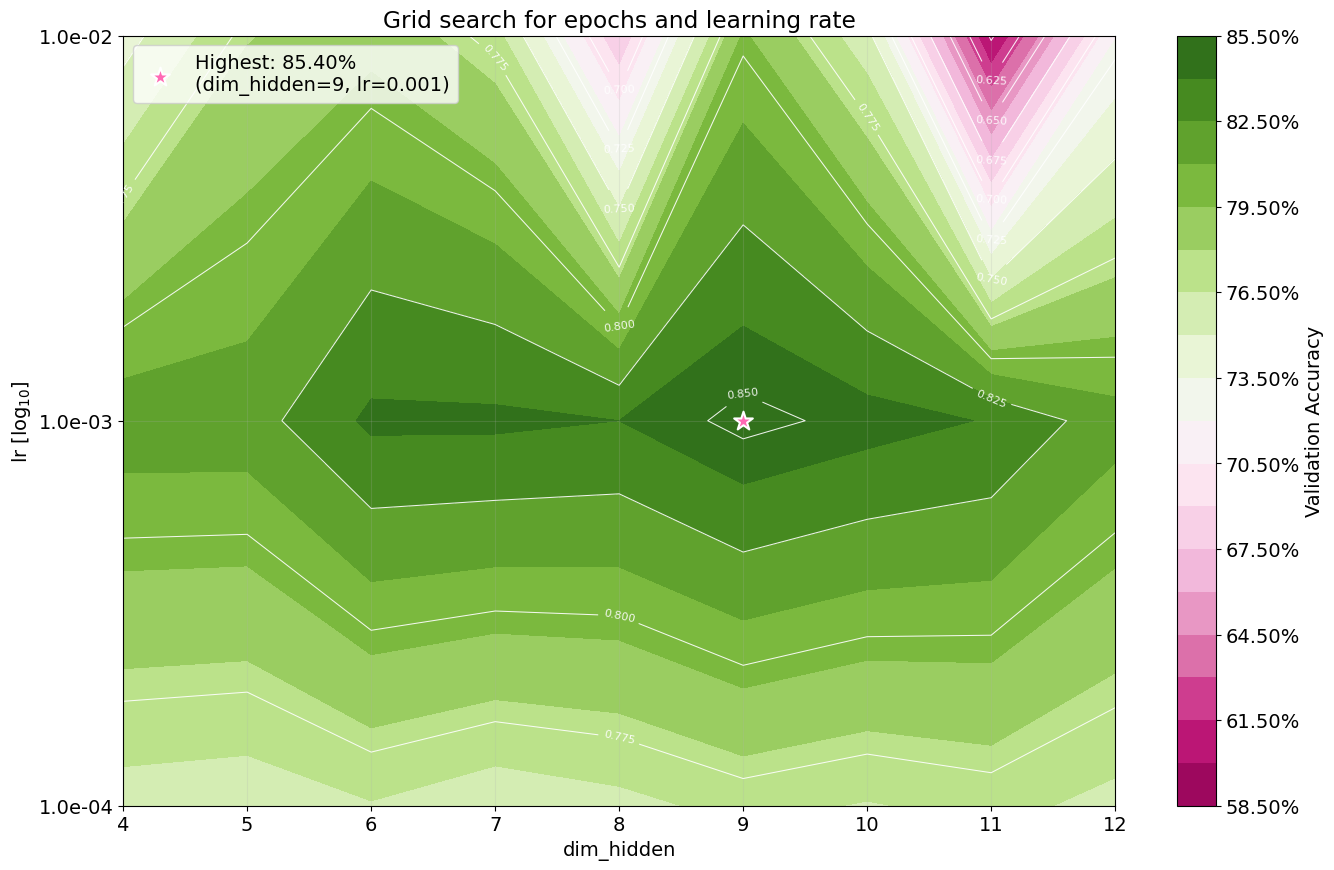

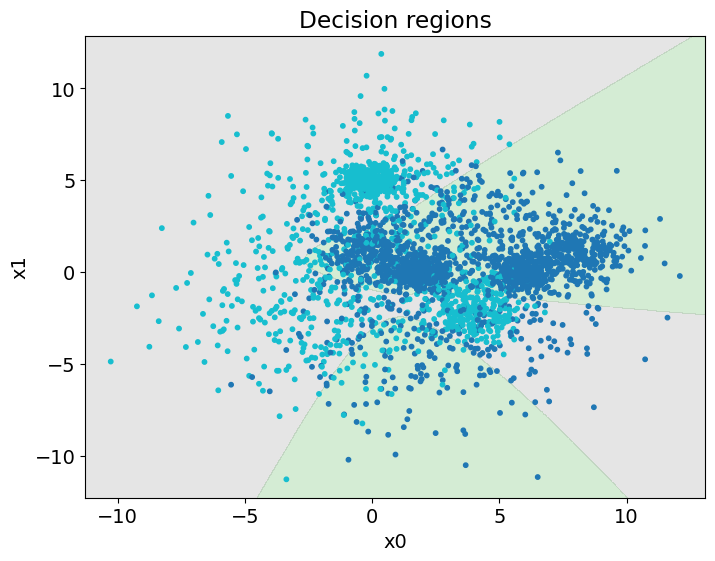

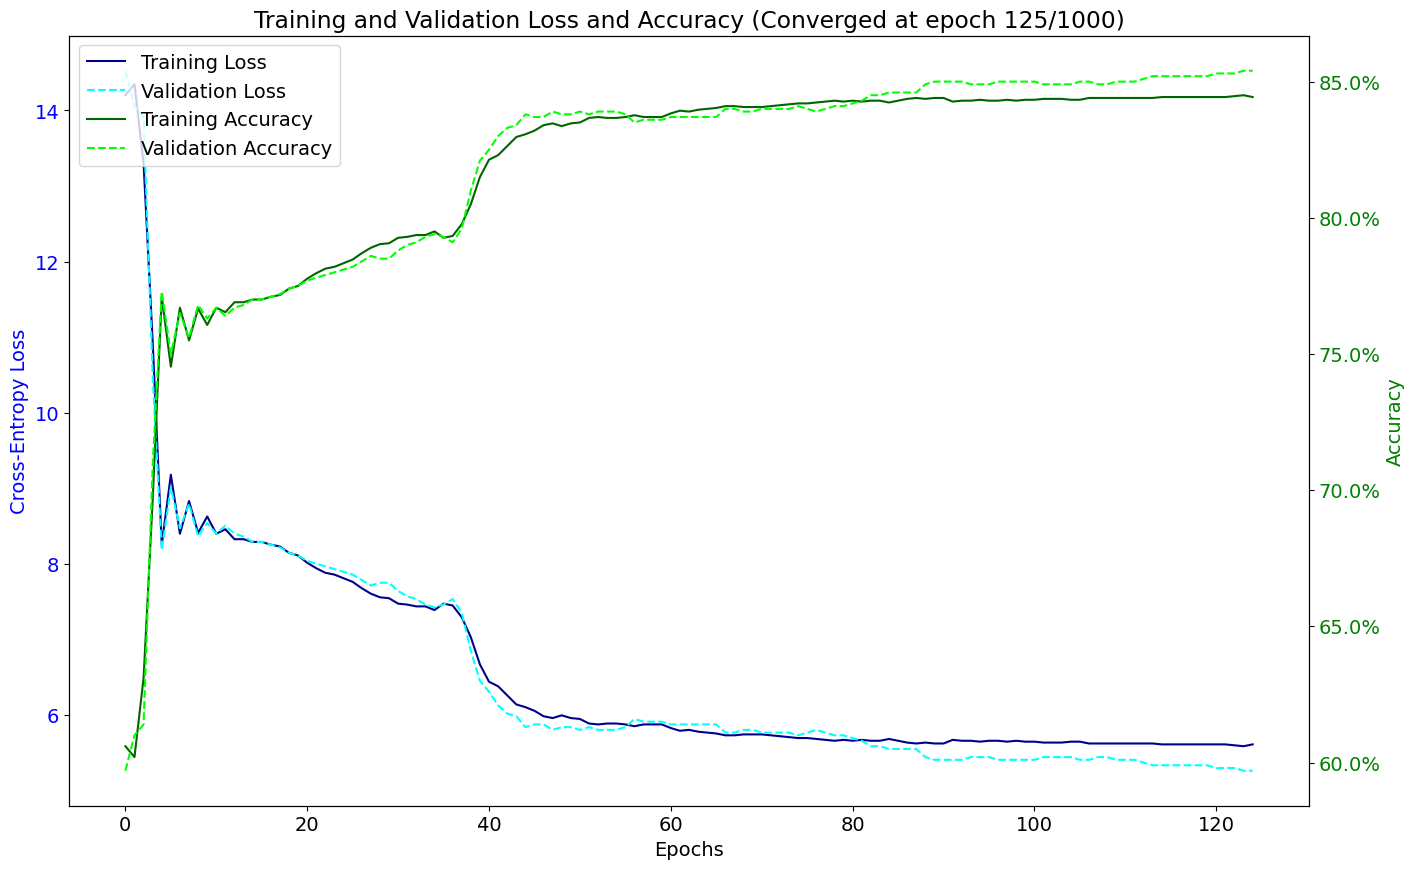

In [49]:
tuner_mlp_improved.plot_search(logy=True)
plt.title("Grid search for epochs and learning rate")
plt.show()

tuner_mlp_improved.plot_regions()

tuner_mlp_improved.plot_loss()
plt.show()

### Showing tolerance making no difference

In [50]:
best_lr = tuner_mlp_improved.best_params['lr'][0]
best_epochs = tuner_mlp_improved.best_params['dim_hidden'][0]

tols = np.logspace(-6, -1, 6)
accuracies = []

for tol in tols:
    mlp_improved = MLPBinaryLinRegClassImproved()
    mlp_improved.fit(X_train, t2_train, lr=best_lr, epochs=best_epochs, X_val=X_val, t_val=t2_val, tol=tol)
    accuracies.append(accuracy(mlp_improved.predict(X_val), t2_val))

In [51]:
table = [["Tolerance", "Accuracy"]]
for tol, acc in zip(tols, accuracies):
    table.append([f"{tol:.0e}", f"{acc:.2%}"])
print(tabulate(table, headers="firstrow", tablefmt="grid", floatfmt=".0e"))

+-------------+------------+
|   Tolerance | Accuracy   |
+=============+============+
|       1e-06 | 59.70%     |
+-------------+------------+
|       1e-05 | 59.70%     |
+-------------+------------+
|       1e-04 | 59.70%     |
+-------------+------------+
|       1e-03 | 59.70%     |
+-------------+------------+
|       1e-02 | 59.70%     |
+-------------+------------+
|       1e-01 | 59.70%     |
+-------------+------------+


### Different Seeds with Optimal Hyperparameters

In [52]:
best_lr = tuner_mlp_improved.best_params['lr'][0]
best_epochs = tuner_mlp_improved.best_params['dim_hidden'][0]

mlp_model1 = MLPBinaryLinRegClassImproved()
mlp_model1.fit(X_train, t2_train, lr=best_lr, epochs=best_epochs, X_val=X_val, t_val=t2_val, tol=1e-5)
acc1 = accuracy(mlp_model1.predict(X_val), t2_val)

mlp_model2 = MLPBinaryLinRegClassImproved(seed=123)
mlp_model2.fit(X_train, t2_train, lr=best_lr, epochs=best_epochs, X_val=X_val, t_val=t2_val, tol=1e-5)
acc2 = accuracy(mlp_model2.predict(X_val), t2_val)

mlp_model3 = MLPBinaryLinRegClassImproved(seed=456)
mlp_model3.fit(X_train, t2_train, lr=best_lr, epochs=best_epochs, X_val=X_val, t_val=t2_val, tol=1e-5)
acc3 = accuracy(mlp_model3.predict(X_val), t2_val)


mean_acc = np.mean([acc1, acc2, acc3])
std_acc = np.std([acc1, acc2, acc3])
print(f"Mean accuracy: {mean_acc:.2%} ± {std_acc**100:.2g}%")

table = [
    ["Model", "Accuracy", "Seed"],
    ["Model 1", f"{acc1:.2%}", 420],
    ["Model 2", f"{acc2:.2%}", 123],
    ["Model 3", f"{acc3:.2%}", 456]
]
print(tabulate(table, headers="firstrow", tablefmt="grid"))

Mean accuracy: 59.70% ± 0%
+---------+------------+--------+
| Model   | Accuracy   |   Seed |
+=========+============+========+
| Model 1 | 59.70%     |    420 |
+---------+------------+--------+
| Model 2 | 59.70%     |    123 |
+---------+------------+--------+
| Model 3 | 59.70%     |    456 |
+---------+------------+--------+


## For IN4050-students: Multi-class neural network

The following part is only mandatory for IN4050 students. IN3050 students are also welcome to make it a try. This is the most fun part of the set :) )

The goal is to use a feed-forward neural network for non-linear multi-class classfication and apply it to the set `(X, t_multi)`.

Modify the network to become a multi-class multinomial classifier. As a sanity check of your implementation, you may apply it to `(X, t_2)` and see whether you get similar results as above.

Train the resulting classifier on `(X_train, t_multi_train)`, test it on `(X_val, t_multi_val)`, tune the hyper-parameters and report the accuracy.

Plot the decision boundaries for your best classifier. Evaluate the  best model predictions for each class separately (same as in part 1)  and report your findings. Please also report whether there is any difference in this respect between the training and the validation sets.

In [53]:
class MLPMultiClass(NumpyClassifier):
    """A multi-layer neural network with one hidden layer for multi-class classification"""
    
    def __init__(self, bias=-1, dim_hidden = 6, num_classes=10, seed=420):
        """Intialize the hyperparameters"""
        self.bias = bias
        self.num_classes = num_classes
        self.dim_hidden = dim_hidden
        self.activ = logistic
        self.activ_diff = logistic_diff
        self.seed = seed
            
    def softmax(self, z):
        """Compute the softmax of input matrix z"""
        # For numerical stability, subtract the max of each row
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward(self, X):
        """
        Perform one forward step. 
        Return a pair consisting of the outputs of the hidden_layer
        and the outputs on the final layer
        """
        # Compute the outputs of the hidden layer
        hidden_inputs = X @ self.weights1
        hidden_outs = add_bias(self.activ(hidden_inputs), self.bias)
        
        # Compute the outputs of the final layer
        final_inputs = hidden_outs @ self.weights2
        # Use softmax activation for multi-class
        outputs = self.softmax(final_inputs)
        
        return hidden_outs, outputs

    def _to_one_hot(self, t):
        """Convert class labels to one-hot encoding"""
        N = t.shape[0]
        one_hot = np.zeros((N, self.num_classes))
        one_hot[np.arange(N), t] = 1
        return one_hot

    def fit(self, X_train, t_train, lr=0.1, epochs=10, X_val=None, t_val=None, 
            tol=1e-5, n_epochs_no_update=2, min_epochs=0, dim_hidden=None):
        """Fit the multi-class MLP model"""
        self.fit_params = {
            'lr': lr, 'epochs': epochs, 'tol': tol, 
            'n_epochs_no_update': n_epochs_no_update, 'min_epochs': min_epochs
        }
        
        validation = X_val is not None and t_val is not None
        
        # Convert targets to one-hot encoding
        t_train_one_hot = self._to_one_hot(t_train)
        if validation:
            t_val_one_hot = self._to_one_hot(t_val)
        
        # Add bias to input features
        X_train_bias = add_bias(X_train, self.bias)
        if validation:
            X_val_bias = add_bias(X_val, self.bias)
        
        # Initialize weights
        if dim_hidden is not None:
            self.dim_hidden = dim_hidden
            self.fit_params['dim_hidden'] = dim_hidden
        
        dim_in = X_train.shape[1]
        dim_out = self.num_classes
        
        np.random.seed(self.seed)
        self.weights1 = (np.random.rand(dim_in + 1, self.dim_hidden) * 2 - 1) / np.sqrt(dim_in)
        self.weights2 = (np.random.rand(self.dim_hidden + 1, dim_out) * 2 - 1) / np.sqrt(self.dim_hidden)
        
        # Initialize tracking variables
        self.loss = []
        self.accuracy = []
        self.val_loss = []
        self.val_accuracy = []
        self.convergence_epoch = None
        
        # Training loop
        for e in range(epochs):
            # Check for early stopping
            if e > min_epochs and e >= n_epochs_no_update:
                loss_avg = self.loss[e-n_epochs_no_update]
                improvement = loss_avg - self.loss[-1]
                if improvement < tol:
                    self.convergence_epoch = e
                    break
            
            # Forward pass
            hidden_outs, outputs = self.forward(X_train_bias)
            
            # Backpropagation
            # Output layer error
            out_errors = outputs - t_train_one_hot
            
            # Hidden layer error
            hidden_errors = out_errors @ self.weights2.T
            hidden_deltas = hidden_errors[:, 1:] * self.activ_diff(hidden_outs[:, 1:])
            
            # Update weights
            self.weights2 -= lr * hidden_outs.T @ out_errors
            self.weights1 -= lr * X_train_bias.T @ hidden_deltas
            
            # Calculate and store loss/accuracy
            self.loss.append(self.cross_entropy_loss(X_train_bias, t_train_one_hot))
            self.accuracy.append(accuracy(self.predict(X_train), t_train))
            
            # Validation metrics
            if validation:
                self.val_loss.append(self.cross_entropy_loss(X_val_bias, t_val_one_hot))
                self.val_accuracy.append(accuracy(self.predict(X_val), t_val))
        
        if self.convergence_epoch is None:
            self.convergence_epoch = epochs

    def cross_entropy_loss(self, X, t_one_hot):
        """Calculate categorical cross-entropy loss"""
        _, y_pred = self.forward(X)
        # Add small epsilon to avoid log(0)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = -np.sum(t_one_hot * np.log(y_pred)) / t_one_hot.shape[0]
        return loss

    def predict_probabilities(self, X):
        """Predict class probabilities"""
        # Add bias if needed
        if X.shape[1] == self.weights1.shape[0] - 1:
            X = add_bias(X, self.bias)
        _, probs = self.forward(X)
        return probs

    def predict(self, X):
        """Predict the class with highest probability"""
        probs = self.predict_probabilities(X)
        return np.argmax(probs, axis=1)

    def plot_loss(self):
        """Plot training and validation loss and accuracy"""
        plt.figure(figsize=(10, 6))
        
        # Plot loss
        plt.plot(self.loss, label='Training Loss', color='darkblue')
        if self.val_loss:
            plt.plot(self.val_loss, label='Validation Loss', color='aqua', linestyle='--')
        lines_loss, labels_loss = plt.gca().get_legend_handles_labels()
        plt.ylabel('Cross-Entropy Loss', color='blue')
        plt.yticks(color='blue')
        plt.xlabel('Epochs')
        
        # Plot accuracy on second y-axis
        plt.twinx()
        plt.plot(self.accuracy, label='Training Accuracy', color='darkgreen')
        if self.val_accuracy:
            plt.plot(self.val_accuracy, label='Validation Accuracy', color='lime', linestyle='--')
        lines_acc, labels_acc = plt.gca().get_legend_handles_labels()
        plt.ylabel('Accuracy', color='green')
        plt.yticks(color='green')
        percentage_formatter = lambda x, _: f'{x:.1%}'
        plt.gca().yaxis.set_major_formatter(FuncFormatter(percentage_formatter))
        
        plt.title(f'Training progress (converged at epoch {self.convergence_epoch}/{self.fit_params["epochs"]})')
        plt.legend(lines_loss + lines_acc, labels_loss + labels_acc)
        
        return plt.gcf()

    def evaluate_per_class(self, X, t):
        """Evaluate model performance for each class separately"""
        y_pred = self.predict(X)
        metrics = {}
        
        for class_idx in range(self.num_classes):
            class_mask = (t == class_idx)
            if np.sum(class_mask) > 0:
                # Accuracy for this class
                correct = (y_pred[class_mask] == class_idx)
                accuracy_class = np.mean(correct)
                
                # Precision for this class
                predicted_as_class = (y_pred == class_idx)
                if np.sum(predicted_as_class) > 0:
                    precision = np.sum((t[predicted_as_class] == class_idx)) / np.sum(predicted_as_class)
                else:
                    precision = 0
                
                # Recall for this class
                recall = np.sum((y_pred[class_mask] == class_idx)) / np.sum(class_mask)
                
                metrics[class_idx] = {
                    'accuracy': accuracy_class,
                    'precision': precision,
                    'recall': recall,
                    'samples': np.sum(class_mask)
                }
        
        return metrics

In [54]:
learning_rates = np.logspace(-6, -3, 4)
epochs = np.arange(400, 1400, 400)
grid_params = {'epochs': epochs, 'lr': learning_rates}

func_params = {'tol': 1e-3, 'X_val': X_val, 't_val': t_multi_val, 'n_epochs_no_update': 10, 'min_epochs': 100}
tuner_mlp_multi = HyperparameterTuner(MLPMultiClass(), grid_params, func_params)

In [55]:
tuner_mlp_multi.search(X_train, t_multi_train, X_val, t_multi_val)

epochs: 100%|██████████| 3/3 [00:09<00:00,  3.17s/it]


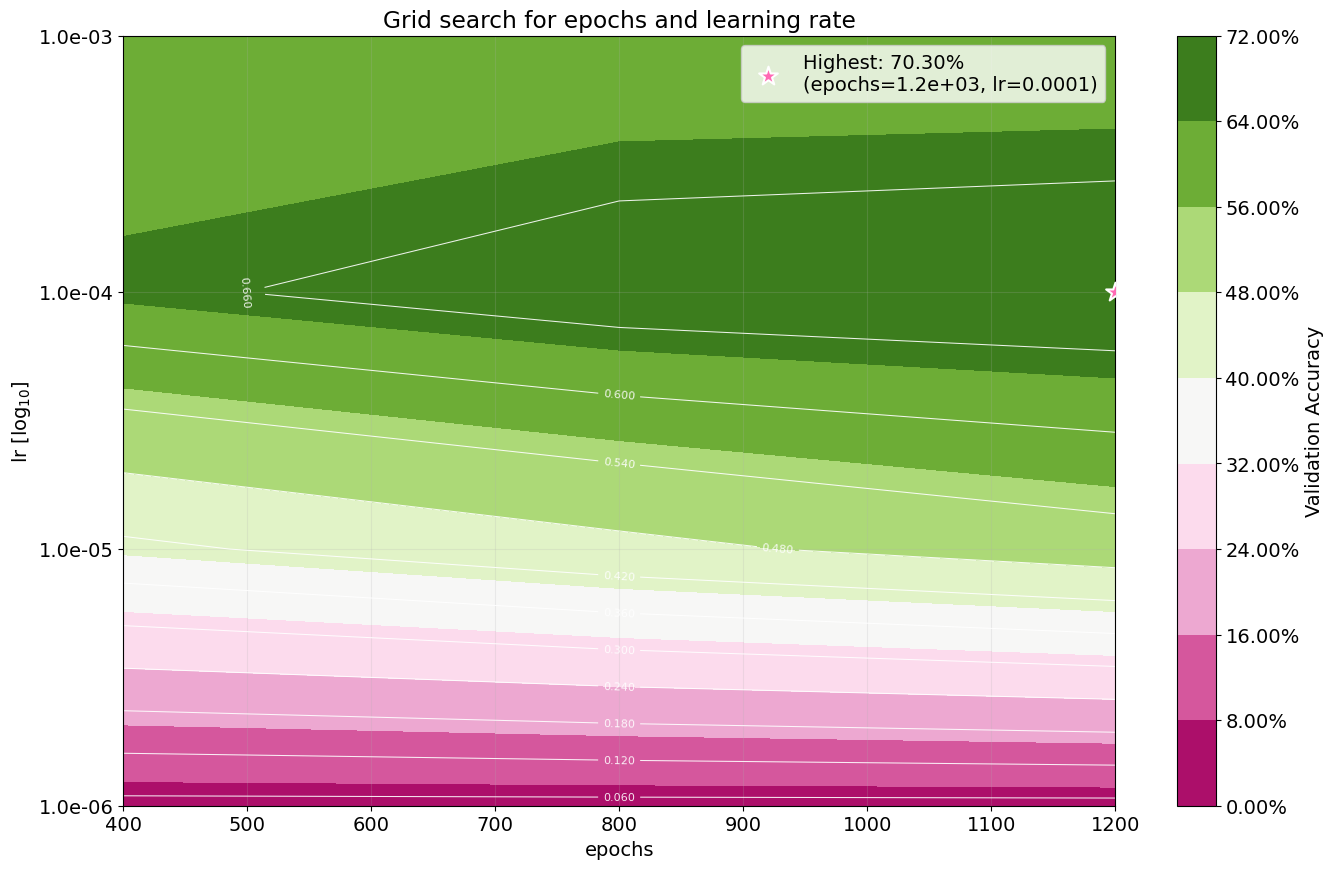

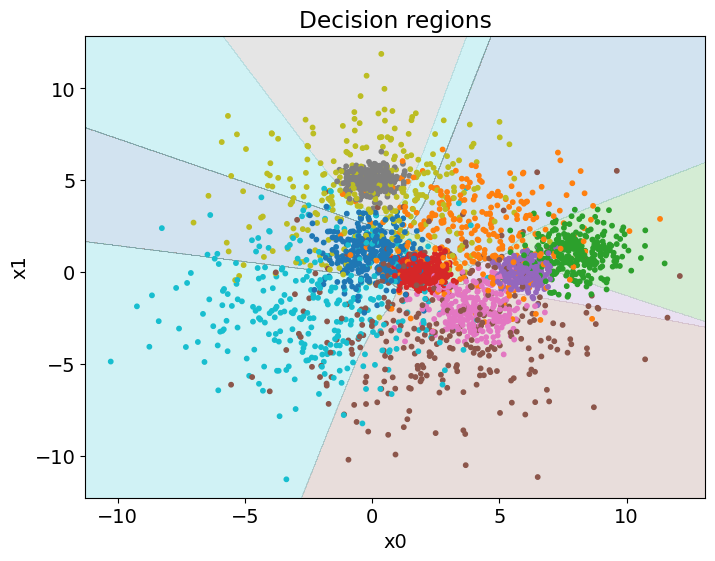

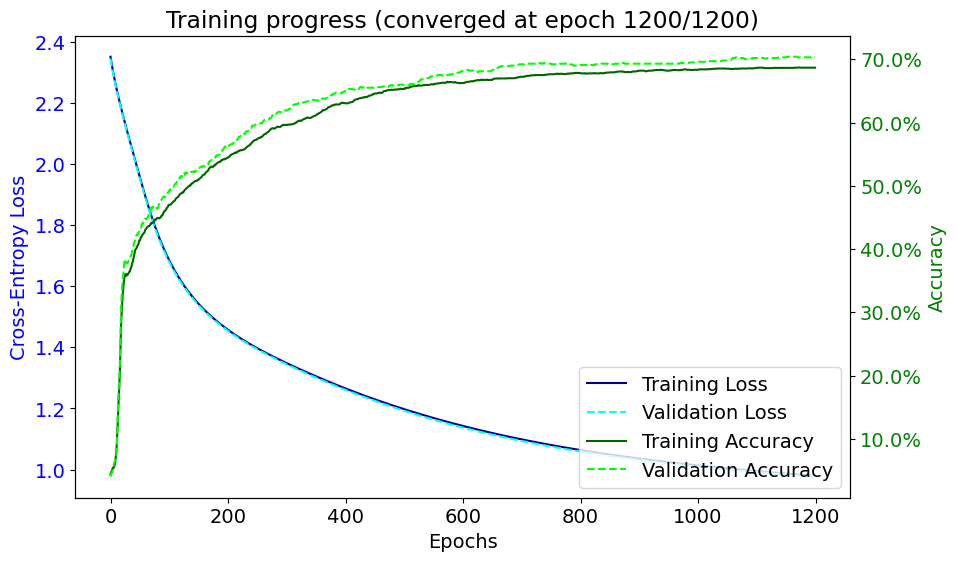

In [56]:
tuner_mlp_multi.plot_search(logy=True)
plt.title("Grid search for epochs and learning rate")
plt.show()
tuner_mlp_multi.plot_regions()
tuner_mlp_multi.best_classifiers[0].plot_loss()
plt.show()

# Part III: Final testing
We can now perform a final testing on the held-out test set we created in the beginning.

## Binary task (X, t2)
Consider the linear regression classifier, the logistic regression classifier and the multi-layer network with the best settings you found. Train each of them on the training set and evaluate on the held-out test set, but also on the validation set and the training set. Report the performance in a 3 by 3 table.

Comment on what you see. How do the three different algorithms compare? Also, compare the results between the different dataset splits. In cases like these, one might expect slightly inferior results on the held-out test data compared to the validation and training data. Is this the case? 

Also report precision and recall for class 1.

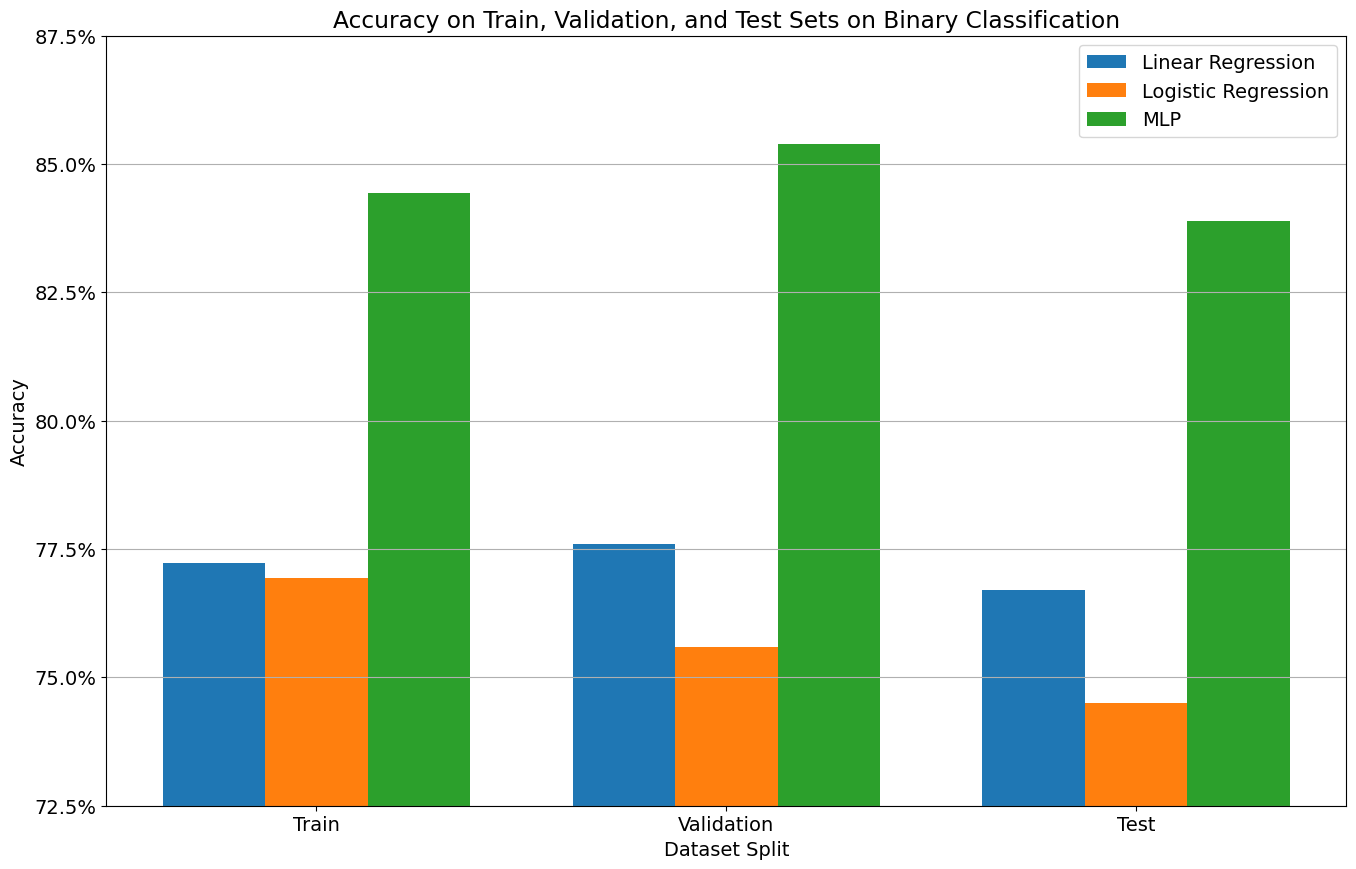

In [57]:
best_linreg = tuner_linreg_scaled.best_classifiers[0]
best_logreg = tuner_logreg_scaled.best_classifiers[0]
best_mlp = tuner_mlp_improved.best_classifiers[0]

# Calculate accuracies for each classifier on train, validation, and test sets
linreg_accuracies = [
    accuracy(best_linreg.predict(X_train_scaled), t2_train),
    accuracy(best_linreg.predict(X_val_scaled), t2_val),
    accuracy(best_linreg.predict(X_test), t2_test)
]

logreg_accuracies = [
    accuracy(best_logreg.predict(X_train_scaled), t2_train),
    accuracy(best_logreg.predict(X_val_scaled), t2_val),
    accuracy(best_logreg.predict(X_test), t2_test)
]

mlp_accuracies = [
    accuracy(best_mlp.predict(X_train), t2_train),
    accuracy(best_mlp.predict(X_val), t2_val),
    accuracy(best_mlp.predict(X_test), t2_test)
]

# Bar plot
labels = ['Train', 'Validation', 'Test']
x = np.arange(len(labels))  # Label locations
width = 0.25  # Bar width

plt.bar(x - width, linreg_accuracies, width, label='Linear Regression')
plt.bar(x, logreg_accuracies, width, label='Logistic Regression')
plt.bar(x + width, mlp_accuracies, width, label='MLP')

# Add labels, title, and legend
plt.xlabel('Dataset Split')
plt.xticks(x, labels)
plt.ylabel('Accuracy')
plt.yticks(np.arange(0.7, 1.0, 0.025), color='black')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.1%}'))
plt.ylim(.725, .875)

plt.title('Accuracy on Train, Validation, and Test Sets on Binary Classification')
plt.legend()
plt.grid(axis='y')
plt.show()

## Conclusion
- The logistic regression classifier was the third best (worst) in all cases. This might not be suprising as we saw clear signs of overfitting when looking at the loss.  
- The linear regression classifier was the second best and performed better on the validation set than the training set, but worse on the test set.
- The MLP classifier was the best in all cases. It performed better on the validation set, but worse on the test set. 

## For IN4050-students: Multi-class task (X, t_multi)

The following part is only mandatory for IN4050-students. IN3050-students are also welcome to give it a try though.

Compare the three multi-class classifiers: the standard multi-class and the multinomial logistic regression from part one and the multi-class neural network from part two. Evaluate on test, validation and training set as above.

Comment on the results.

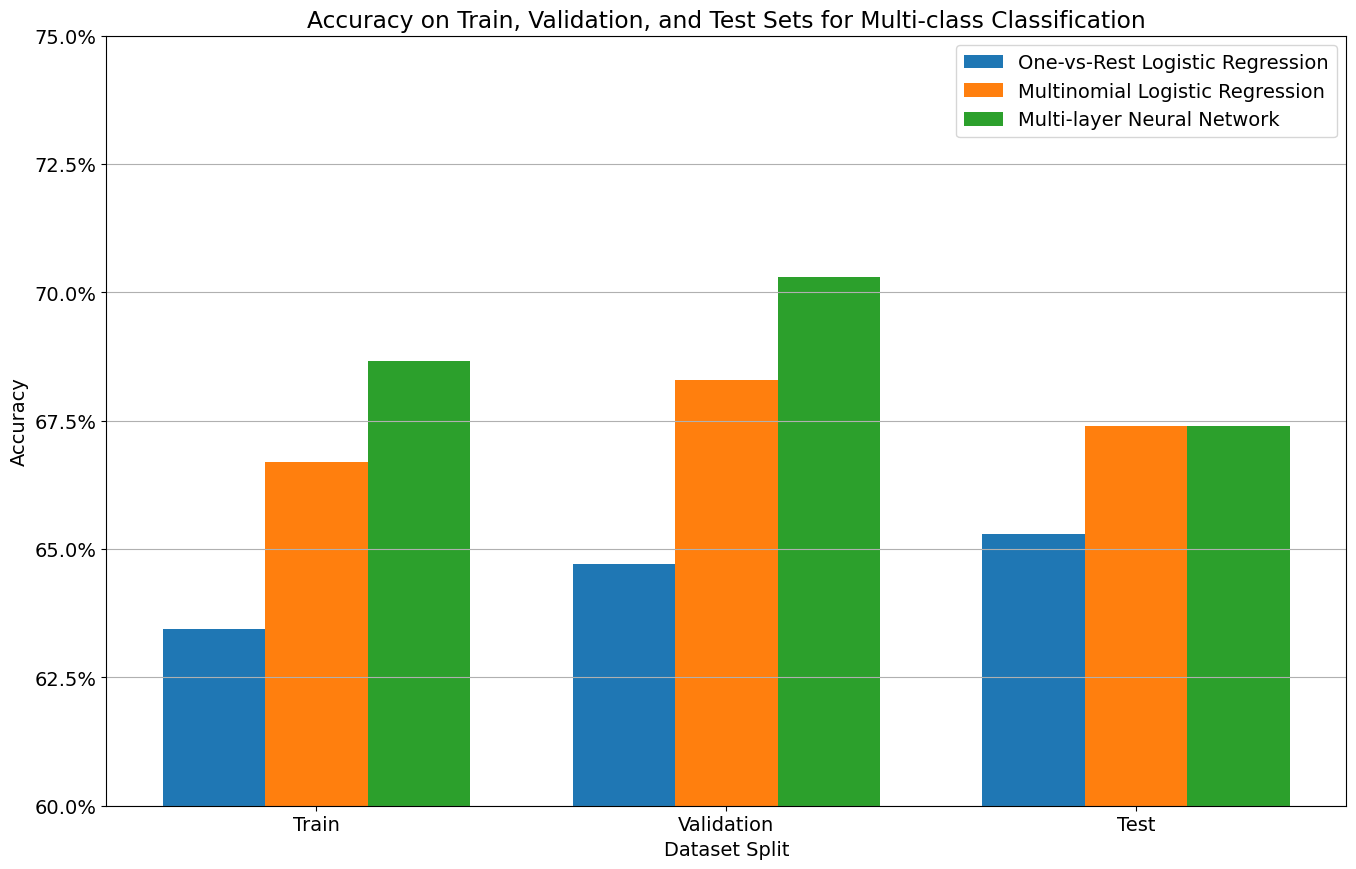

+---------+--------------+------------+---------------+-------------+-----------------+---------------+
|   Class | Train Acc.   | Val Acc.   | Train Prec.   | Val Prec.   |   Train Samples |   Val Samples |
+=========+==============+============+===============+=============+=================+===============+
|       0 | 68.9%        | 67.7%      | 61.2%         | 61.8%       |             309 |            93 |
+---------+--------------+------------+---------------+-------------+-----------------+---------------+
|       1 | 52.0%        | 60.6%      | 68.9%         | 68.2%       |             298 |            99 |
+---------+--------------+------------+---------------+-------------+-----------------+---------------+
|       2 | 85.2%        | 89.8%      | 77.5%         | 77.0%       |             291 |           108 |
+---------+--------------+------------+---------------+-------------+-----------------+---------------+
|       3 | 96.8%        | 96.7%      | 69.7%         | 71.5%   

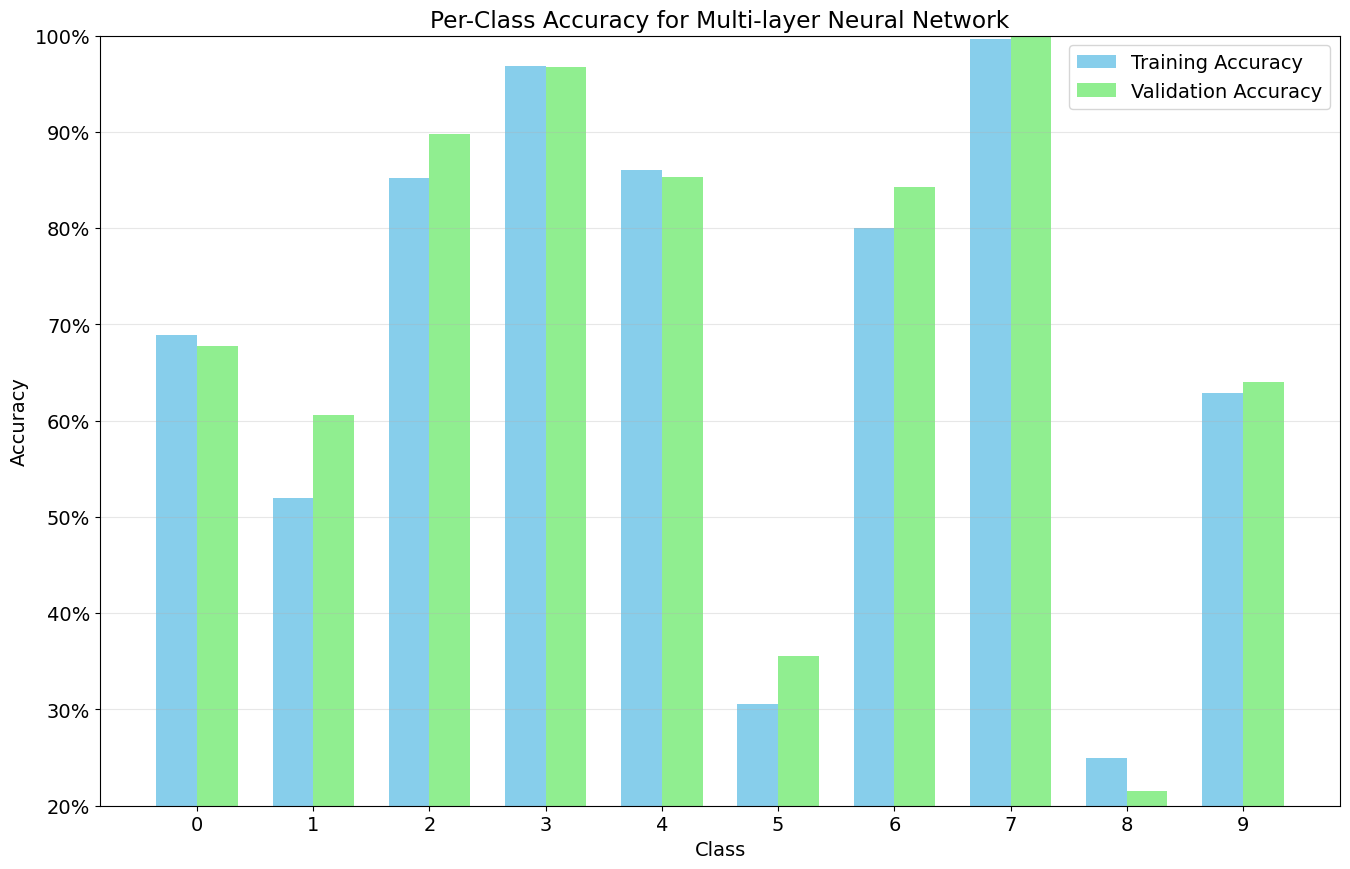

In [58]:
# Get the best models for each multi-class classifier
best_ovr_logreg = tuner_multi_class.best_classifiers[0]  # One-vs-Rest logistic regression
best_multinomial = tuner_multinomial.best_classifiers[0]  # Multinomial logistic regression
best_mlp_multi = tuner_mlp_multi.best_classifiers[0]  # Multi-layer neural network

ovr_accuracies = [
    accuracy(best_ovr_logreg.predict(X_train), t_multi_train),
    accuracy(best_ovr_logreg.predict(X_val), t_multi_val),
    accuracy(best_ovr_logreg.predict(X_test), t_multi_test)
]

multinomial_accuracies = [
    accuracy(best_multinomial.predict(X_train), t_multi_train),
    accuracy(best_multinomial.predict(X_val), t_multi_val),
    accuracy(best_multinomial.predict(X_test), t_multi_test)
]

mlp_multi_accuracies = [
    accuracy(best_mlp_multi.predict(X_train), t_multi_train),
    accuracy(best_mlp_multi.predict(X_val), t_multi_val),
    accuracy(best_mlp_multi.predict(X_test), t_multi_test)
]

# Bar plot
labels = ['Train', 'Validation', 'Test']
x = np.arange(len(labels))
width = 0.25

plt.bar(x - width, ovr_accuracies, width, label='One-vs-Rest Logistic Regression')
plt.bar(x, multinomial_accuracies, width, label='Multinomial Logistic Regression')
plt.bar(x + width, mlp_multi_accuracies, width, label='Multi-layer Neural Network')

plt.xlabel('Dataset Split')
plt.xticks(x, labels)
plt.ylabel('Accuracy')
plt.ylim(0.6, .75)
plt.yticks(np.arange(0.6, 0.75, 0.025), color='black')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.1%}'))

plt.title('Accuracy on Train, Validation, and Test Sets for Multi-class Classification')
plt.legend()
plt.grid(axis='y')
plt.show()

# Add per-class evaluation for the best model (MLP)
train_metrics = best_mlp_multi.evaluate_per_class(X_train, t_multi_train)
val_metrics = best_mlp_multi.evaluate_per_class(X_val, t_multi_val)

classes = range(10)
bar_width = 0.35
x_train = np.arange(len(classes))
x_val = x_train + bar_width

plt.bar(x_train, [train_metrics[c]['accuracy'] for c in classes], bar_width, 
        label='Training Accuracy', color='skyblue')
plt.bar(x_val, [val_metrics[c]['accuracy'] for c in classes], bar_width,
        label='Validation Accuracy', color='lightgreen')

# Add labels and other details
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.ylim(0.2, 1)
plt.title('Per-Class Accuracy for Multi-layer Neural Network')
plt.xticks(x_train + bar_width/2, classes)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0%}'))


metrics_table = []
for c in classes:
    metrics_table.append([
        c,
        f"{train_metrics[c]['accuracy']:.1%}",
        f"{val_metrics[c]['accuracy']:.1%}",
        f"{train_metrics[c]['precision']:.1%}",
        f"{val_metrics[c]['precision']:.1%}",
        train_metrics[c]['samples'],
        val_metrics[c]['samples']
    ])

headers = ["Class", "Train Acc.", "Val Acc.", "Train Prec.", "Val Prec.", "Train Samples", "Val Samples"]
print(tabulate(metrics_table, headers=headers, tablefmt="grid"))